<div style="display: flex; background-color: RGB(104,157,113);" >
<h1 style="margin: auto; padding: 30px; ">ETUDE DE MARCHE LA POULE QUI CHANTE</h1>
</div>

In [1]:
# Importation des librairies nécessaires à la préparation, au nettoyage puis à l'analyse exploratoire des données

import pandas as pd                 # pour lire, manipuler et représenter les données sous forme de dataframes (tableaux pouvant contenir plusieurs types de données)
import numpy as np                  # pour effectuer des opérations numériques complexes sur arrays (tableaux contenant un type de données unique)
import matplotlib.pyplot as plt     # pour pouvoir créer des graphiques simples
import seaborn as sns               # pour pouvoir créer des graphiques plus complexes
import copy                         # pour pouvoir effectuer des copies de dataframe pour les analyses


In [2]:

import os                               # importe la librairie os 
os.environ["OMP_NUM_THREADS"] = "1"     # limite le nombre de threads utilisés par MKL à 1, pour éviter le conflit de mémoire de scikit-learn avec Microsoft.


In [3]:
# Chargement du fichier à analyser

datas = pd.read_csv("Etude_de_marche_Poule_qui_Chante.csv", sep = ",", index_col = "Pays")     # indication que les colonnes sont séparées par des "," pour la lecture et la séparation et que Pays représente la colonne des index (exclue cette variable pour l'ACP)

datas.head()                                                                                   # affichage des 5 premières lignes du tableau pour vérifier que le chargement et la séparation des colonnes sont corrects


,Population_totale,%Population_urbaine,PIB,Pouvoir_achat,Taux_change,%conso_volaille,%import_volaille,%Accès_internet,%Droits_douanes,Stabilite_politique,%Agri_bio
Pays,,,,,,,,,,,
ALBANIE,2884169.0,60.33,1.301973e+10,4357.51,119.100000,1.29,80.85,62.4000,0.85,0.373771,0.05
ALGÉRIE,41389189.0,71.93,1.700970e+11,3584.64,110.973017,0.80,0.76,47.6911,9.38,-0.919614,0.00
ALLEMAGNE,82658409.0,76.75,3.763092e+12,44574.38,0.885206,2.06,52.33,84.3942,1.96,0.574381,8.21
ARABIE SAOUDITE,33101179.0,83.21,7.149947e+11,23294.86,3.750000,7.93,50.31,94.1756,4.85,-0.649626,0.01
ARGENTINE,43937140.0,92.45,6.436284e+11,10397.42,16.562707,5.44,0.43,74.2949,7.93,0.162542,3.04


In [4]:
# Vérification du nombre de Pays présents et du pourcentage de population mondiale couvert

nb_pays_datas = len(datas.index.tolist())                                         # récupère les noms de pays (index) dans une liste et compte le nombre de valeurs présentes dans la liste
pop_monde = 7500000000                                                            # population mondiale de 2017 = 7,5 milliards
pop_couverte = round((datas["Population_totale"].sum() * 100 / pop_monde), 2)     # calcule la somme des populations totales des pays présents dans le fichier Merge et divise par la population mondiale de 2017 pour obtenir le % de population couverte dans le tableau

print(f"Il y a {nb_pays_datas} pays dans le tableau final. Ils couvrent {pop_couverte} % de la population mondiale de l'année 2017 (7,5 milliards d'habitants).")


Il y a 101 pays dans le tableau final. Ils couvrent 76.0 % de la population mondiale de l'année 2017 (7,5 milliards d'habitants).


<div style="background-color: RGB(189,236,182);" >
<h2 style="margin: auto; padding: 20px; color: black; ">ANALYSE EN COMPOSANTES PRINCIPALES</h2>
</div>

In [5]:
# Récupération des dimensions du tableau

n = datas.shape[0]           # nombre de lignes/individus
p = datas.shape[1]           # nombre de colonnes/variables

print(f"Il y a {n} individus et {p} variables dans le tableau à analyser.")


Il y a 101 individus et 11 variables dans le tableau à analyser.


<div style="border: 1px solid RGB(0,100,0);" >
<h3 style="margin: auto; padding: 20px; color: RGB(189,230,182); ">Centrage-Réduction</h3>
</div>

In [6]:
# Affichage des moyennes et écart-types de chaque variable (arrondis à 2 chiffres après la virgule pour plus de lisibilité)

datas.describe().round(2)


,Population_totale,%Population_urbaine,PIB,Pouvoir_achat,Taux_change,%conso_volaille,%import_volaille,%Accès_internet,%Droits_douanes,Stabilite_politique,%Agri_bio
count,1.010000e+02,101.00,1.010000e+02,101.00,101.00,101.00,101.00,101.00,101.00,101.00,101.00
mean,5.643542e+07,64.15,7.463432e+11,16813.16,688.37,2.70,42.94,61.80,4.53,0.08,3.62
std,1.961098e+08,20.90,2.381401e+12,19250.93,2788.12,1.86,47.94,25.48,4.16,0.81,6.03
min,7.145800e+04,16.25,5.207000e+08,413.55,0.30,0.18,0.00,6.40,0.49,-1.97,0.00
25%,4.056099e+06,50.10,1.416134e+10,3215.43,1.00,1.48,4.78,43.83,1.96,-0.38,0.16
50%,9.904896e+06,67.53,9.597813e+10,8056.67,6.91,2.11,23.58,67.10,2.22,0.08,0.83
75%,3.558126e+07,81.90,4.017453e+11,23294.86,107.82,3.49,74.47,81.58,6.10,0.75,4.61
max,1.421022e+09,101.98,1.961210e+13,81020.96,22370.09,8.18,234.72,98.26,18.49,1.56,37.60


In [7]:
# Afin que toutes les données puissent être comparables, nous allons centrer leurs valeurs pour que le centre de gravité du nuage de point coïncide avec le centre/origine du repère et ainsi que tous les vecteurs aient le même point de départ
#(= rendre toutes les moyennes égales), puis nous allons les réduire afin de les normaliser en les rapportant toutes à la même unité (= rendre toutes les variances/ecarts-types égales)

from sklearn.preprocessing import StandardScaler        # importe la librairie utile au centrage-réduction des données

scaler = StandardScaler()                               # indique quel outil utiliser pour le centrage-réduction (= standardisation des données en transformant toutes les moyennes = 0 et tous les écarts-types = 1)
datas_scaled = scaler.fit_transform(datas)              # fit calcule la moyenne et l'écart-type de chaque colonne, tranform applique la transformation pour que moyenne = 0 et ecart-type = 1
datas_scaled = pd.DataFrame(datas_scaled)               # transforme les données obtenues en un nouveau dataframe
datas_scaled.describe().round(2)                        # affichage des 5 premières lignes du tableau pour vérifier que les modifications ont bien été apportées et sont correctes

## => toutes les moyennes sont bien devenues = 0 (centrage) et les ecart-types = 1 (réduction).


,0,1,2,3,4,5,6,7,8,9,10
count,101.00,101.00,101.00,101.00,101.00,101.00,101.00,101.00,101.00,101.00,101.00
mean,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.29,-2.30,-0.31,-0.86,-0.25,-1.36,-0.90,-2.19,-0.98,-2.56,-0.60
25%,-0.27,-0.68,-0.31,-0.71,-0.25,-0.66,-0.80,-0.71,-0.62,-0.57,-0.58
50%,-0.24,0.16,-0.27,-0.46,-0.25,-0.32,-0.41,0.21,-0.56,0.01,-0.46
75%,-0.11,0.85,-0.15,0.34,-0.21,0.43,0.66,0.78,0.38,0.84,0.16
max,6.99,1.82,7.96,3.35,7.82,2.96,4.02,1.44,3.37,1.85,5.66


<div style="border: 1px solid RGB(0,100,0);" >
<h3 style="margin: auto; padding: 20px; color: RGB(189,230,182); ">Composantes Principales</h3>
</div>

In [8]:
# Application de l'Analyse en Composantes Principales, création du modèle

from sklearn.decomposition import PCA                # importe la librairie utile pour faire l'ACP (PCA en anglais)

acp = PCA()                                          # indique quel outil utiliser pour réaliser l'ACP  (ici on conserve toutes les composantes principales par défaut mais on n'aurait pu préciser le nombre de composantes à analyser dans les paramètres)
datas_acp = acp.fit_transform(datas_scaled)          # applique l'ACP, fit calcule les coordonnées de chaque individu standardisé et transform projette les données initiales sur les nouvelles composantes
datas_acp                                            # affiche les nouvelles coordonnées de chaque individu standardisé                                          


array([[-0.18391727, -0.59658388,  0.03455857, ..., -0.07007246,
        -0.37471738,  0.06475507],
       [-1.7048459 ,  0.46137091, -0.75099859, ...,  0.34939167,
        -0.53849238,  0.00517255],
       [ 2.00685783,  0.48118697,  1.14615643, ..., -0.57757319,
        -0.04736561, -0.05100107],
       ...,
       [ 1.16898813, -0.71651119,  0.38612429, ...,  1.00737098,
        -1.57108261, -0.3750614 ],
       [-1.63243255, -2.10754344,  1.83610194, ..., -0.29937601,
         0.08671648,  0.03335346],
       [-2.15489471,  0.49825082,  0.11589315, ..., -0.14866031,
         0.17113322,  0.51626608]])

L'inertie totale représentée par les composantes et de 100.0 %.
Valeurs propres des composantes : [3.62 1.82 1.27 1.03 0.81 0.72 0.57 0.41 0.38 0.24 0.13]


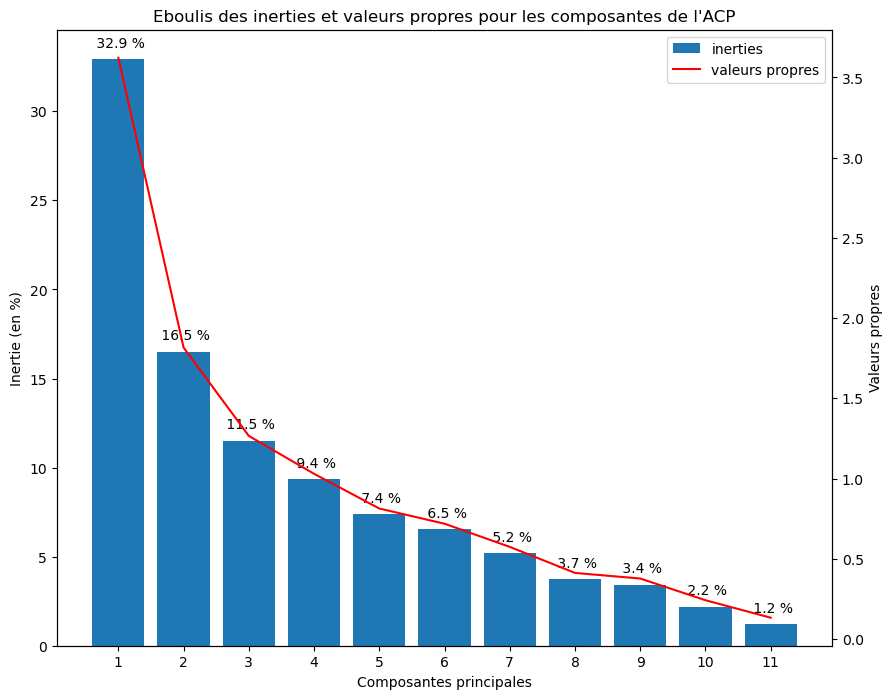

In [9]:
# Choix du nombre de composantes à étudier grâce à l'éboulis des valeurs propres (% d'inertie) + méthode des batons brisés

inerties = acp.explained_variance_ratio_ * 100                                                     # calcule les taux d'inertie pour chaque axe/composante
inertie_totale = inerties.sum().round(2)                                                           # calcule le pourcentage d'inertie totale représenté par les composantes de l'ACP, pour vérifier que les données sont bien toutes représentées (100 %).
print(f"L'inertie totale représentée par les composantes et de {inertie_totale} %.")   

val_propres = (n - 1) / n * acp.explained_variance_                                                # calcule les valeurs propres pour chaque axe/composante
print(f"Valeurs propres des composantes : {val_propres.round(2)}")

plt.figure(figsize = (10,8))                                                                       # ajuste la taille de la future figure pour une bonne lisibilité
ax1 = plt.gca()                                                                                    # récupère l'axe des ordonnées à gauche (y, vertical)
ax2 = ax1.twinx()                                                                                  # crée un 2ème axe des ordonnées à droite (y, vertical)
bars = ax1.bar(range(1, len(inerties) + 1), inerties, label = "inerties")                          # crée l'éboulis des inerties des composantes de l'ACP (sous forme d'histogramme)
for bar in bars :                                                                                  # crée une boucle qui récupère les informations de hauteur des barres pour afficher les valeurs d'inertie au-dessus de chaque barre
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2., height + 0.5, f"{height : .1f} %", ha = "center", va = "bottom")
ax2.plot(range(1, len(val_propres) + 1), val_propres, color = "red", label = "valeurs propres")    # crée l'éboulis des valeurs propres des composantes de l'ACP (sous forme de courbe)
ax1.set_xlabel("Composantes principales")                                                          # ajoutent des titres au graphique pour une meilleure compréhension de l'information visualisée
plt.xticks(range(1, len(inerties) + 1))                                                            # assure que chaque composante est bien marquée sur l'axe des abscisses (x, horizontal)
ax1.set_ylabel("Inertie (en %)")
ax2.set_ylabel("Valeurs propres")
plt.title("Eboulis des inerties et valeurs propres pour les composantes de l'ACP")
fig = plt.gcf()                                                                                    # récupère la figure actuelle
fig.legend(loc="upper right", bbox_to_anchor = (1, 1), bbox_transform = ax1.transAxes)             # affiche la légende sur le graphique pour plus de compréhension des informations observées (dans le coin en haut à droite de la zone de traçage)
plt.show()                                                                                         # affiche le graphique

## => Si nous nous fions à la 1ère cassure du coude de l'éboulis des valeurs propres (en rouge), nous pourrions conserver les 2 premières composantes pour le reste de l'analyse. 
## => Cependant, ces 2 composantes ne représentent que 49.4 % % des données. Ce n'est pas suffisant pour réaliser l'ACP.
## => Si nous ajoutons alors le critère de Kaiser (= composante conservée si valeur propre > 1), nous obtenons cette fois 4 composantes (inégrées également dans le coude).
## => Cependant, ces 4 composantes ne cumulent que 70 % de l'inertie totale. C'est le minimum acceptable pour une ACP mais cela n'est peut être pas suffisant pour bien représenter nos données. 
## => Même si les composantes 5 et 6 ont une valeur propre < 1, je choisis donc de conserver les 6 premières composantes pour arriver à 84 % de représentation (80 % étant l'idéal pour une bonne représentation des données) et être sûre de bien représenter les données.


In [10]:
# Nota Bene :

# Pour compléter l'analyse et valider le choix des composantes, j'ai essayé également la méthode des batons brisés mais elle ne validait que l'utilisation du 1er axe  (= comparaison entre le seuil d'inertie théorique de la composante et sa valeur réelle 
# avec validation si inertie réelle > seuil théorique). Pour pouvoir former un plan, il aurait donc fallu ne conserver que les composantes 1 et 2 (inertie = 32.9 % et 16.5 %) mais le pourcentage de représentation des données n'est pas suffisant = 49.4 %.
# Nous ne pouvions donc pas conclure sur le choix des composantes avec cette méthode.


<div style="border: 1px solid RGB(0,100,0);" >
<h3 style="margin: auto; padding: 20px; color: RGB(189,230,182); ">Cercle des corrélations</h3>
</div>

<div style="border: 1px solid RGB(0,100,0);" >
<h4 style="margin: auto; padding: 20px; color: RGB(189,230,182); ">Degrès de corrélation</h4>
</div>

In [11]:
# Création du tableau représentant les degrès de corrélations entre les variables initiales et les composantes principales de l'ACP

sqrt_val_propres = np.sqrt(val_propres)                                                       # calcule la racine carré des valeurs propres

correlations_var = pd.DataFrame({"" : datas.columns})                                         # crée un dataframe/tableau dans lequel on pourra stocker les résultats des correlations 
for composante in  range(p) :                                                                 # pour chaque composante de l'ACP (p) :      
    resultat_corr = (acp.components_[composante, :] * sqrt_val_propres[composante]).round(2)  # calcule le degrès de correlation (vecteur propre * racine carré de la valeur propre) entre chaque variable et la composante, arrondi à 2 chiffres après la virgule
    nom_colonne = f"F{composante + 1}"                                                        # crée le nom de la nouvelle colonne à ajouter au tableau (nom de la composante principale)
    correlations_var[nom_colonne] = resultat_corr                                             # ajoute le résultat de la correlation dans la colonne associée

correlations_var                                                                              # affiche le tableau des correlations


,,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11
0,Population_totale,-0.13,0.73,0.50,-0.04,-0.02,-0.01,-0.21,-0.09,0.36,0.12,0.01
1,%Population_urbaine,0.79,0.19,-0.33,-0.01,-0.18,0.09,0.14,-0.26,0.20,-0.21,-0.16
2,PIB,0.22,0.74,0.44,-0.11,-0.01,0.20,0.11,0.05,-0.35,-0.17,-0.00
3,Pouvoir_achat,0.83,0.04,0.18,0.06,-0.04,-0.05,0.40,0.02,-0.06,0.33,-0.08
4,Taux_change,-0.27,0.07,-0.00,0.86,0.30,0.30,0.05,-0.11,-0.00,0.00,-0.01
5,%conso_volaille,0.50,0.14,-0.39,-0.34,0.44,0.43,-0.26,0.03,-0.03,0.12,-0.02
6,%import_volaille,0.10,-0.60,0.41,-0.03,-0.43,0.45,-0.20,-0.17,-0.06,0.05,-0.02
7,%Accès_internet,0.93,0.05,-0.12,0.10,-0.09,-0.02,0.01,-0.12,0.02,-0.02,0.30
8,%Droits_douanes,-0.65,-0.18,0.11,-0.36,0.21,0.30,0.47,-0.10,0.17,-0.04,0.09
9,Stabilite_politique,0.69,-0.34,0.33,0.11,0.12,0.12,0.02,0.44,0.21,-0.14,-0.01


<div style="border: 1px solid RGB(0,100,0);" >
<h4 style="margin: auto; padding: 20px; color: RGB(189,230,182); ">Qualité de représentation des variables</h4>
</div>

In [12]:
# Calcul de la qualité de représentation de chaque variable pour chaque composante principale de l'ACP (proche de 1 = bien représentée, proche de 0 = peu représentée)

qualite_var = copy.deepcopy(correlations_var)                           # crée une copie du tableau des corrélations pour effectuer le calcul de la qualité de représentation des variables sans comprommettre les données des corrélations
numeriques = qualite_var.select_dtypes(include = "number").columns      # sélectionne uniquement les colonnes dont les données sont nuémriques (exclusion de l'index qui est sous format texte)
qualite_var[numeriques] = (qualite_var[numeriques] ** 2).round(3)       # applique à chaque colonne numérique (composante) le calcul de la qualité de représentation (correlation au carré) de chaque variable dans chaque composante, arrondi à 3 chiffres après la virgule

qualite_var                                                             # affiche le tableau de la qualité de représentation de chaque variable


,,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11
0,Population_totale,0.017,0.533,0.250,0.002,0.000,0.000,0.044,0.008,0.130,0.014,0.000
1,%Population_urbaine,0.624,0.036,0.109,0.000,0.032,0.008,0.020,0.068,0.040,0.044,0.026
2,PIB,0.048,0.548,0.194,0.012,0.000,0.040,0.012,0.003,0.122,0.029,0.000
3,Pouvoir_achat,0.689,0.002,0.032,0.004,0.002,0.003,0.160,0.000,0.004,0.109,0.006
4,Taux_change,0.073,0.005,0.000,0.740,0.090,0.090,0.003,0.012,0.000,0.000,0.000
5,%conso_volaille,0.250,0.020,0.152,0.116,0.194,0.185,0.068,0.001,0.001,0.014,0.000
6,%import_volaille,0.010,0.360,0.168,0.001,0.185,0.202,0.040,0.029,0.004,0.003,0.000
7,%Accès_internet,0.865,0.003,0.014,0.010,0.008,0.000,0.000,0.014,0.000,0.000,0.090
8,%Droits_douanes,0.423,0.032,0.012,0.130,0.044,0.090,0.221,0.010,0.029,0.002,0.008
9,Stabilite_politique,0.476,0.116,0.109,0.012,0.014,0.014,0.000,0.194,0.044,0.020,0.000


<div style="border: 1px solid RGB(0,100,0);" >
<h4 style="margin: auto; padding: 20px; color: RGB(189,230,182); ">Contribution des variables</h4>
</div>

In [13]:
# Calcul de la contribution de chaque variable dans chaque composante principale de l'ACP  (proche de 1 = contribue à la composante, proche de 0 = ne contribue pas à la composante)

contribution_var = copy.deepcopy(qualite_var)                                                       # récupèreles données de la qualité de représentation des variables pour pouvoir effectuer le calcul sans compromettre les données précédentes
numeriques = contribution_var.select_dtypes(include = "number").columns                             # sélectionne uniquement les colonnes dont les données sont nuémriques (exclusion de l'index qui est sous format texte)

for index, composante in enumerate(numeriques) :                                                    # pour chaque composante de l'ACP (p, colonne sous format numérique) :    
    contribution_var[composante] = (contribution_var[composante] / val_propres[index]).round(3)     # calcule la contribution de chaque variable dans la composante principale associée en normalisant sa contribution individuelle par sa valeur propre

contribution_var                                                                                    # affiche le tableau de la contribution de chaque variable dans les composantes principales de l'ACP


,,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11
0,Population_totale,0.005,0.293,0.198,0.002,0.000,0.000,0.077,0.019,0.345,0.058,0.000
1,%Population_urbaine,0.172,0.020,0.086,0.000,0.039,0.011,0.035,0.165,0.106,0.182,0.197
2,PIB,0.013,0.302,0.153,0.012,0.000,0.056,0.021,0.007,0.324,0.120,0.000
3,Pouvoir_achat,0.190,0.001,0.025,0.004,0.002,0.004,0.279,0.000,0.011,0.452,0.045
4,Taux_change,0.020,0.003,0.000,0.719,0.111,0.125,0.005,0.029,0.000,0.000,0.000
5,%conso_volaille,0.069,0.011,0.120,0.113,0.239,0.258,0.119,0.002,0.003,0.058,0.000
6,%import_volaille,0.003,0.198,0.133,0.001,0.228,0.281,0.070,0.070,0.011,0.012,0.000
7,%Accès_internet,0.239,0.002,0.011,0.010,0.010,0.000,0.000,0.034,0.000,0.000,0.680
8,%Droits_douanes,0.117,0.018,0.009,0.126,0.054,0.125,0.385,0.024,0.077,0.008,0.060
9,Stabilite_politique,0.131,0.064,0.086,0.012,0.017,0.019,0.000,0.471,0.117,0.083,0.000


<div style="border: 1px solid RGB(0,100,0);" >
<h4 style="margin: auto; padding: 20px; color: RGB(189,230,182); ">Plan 1</h4>
</div>

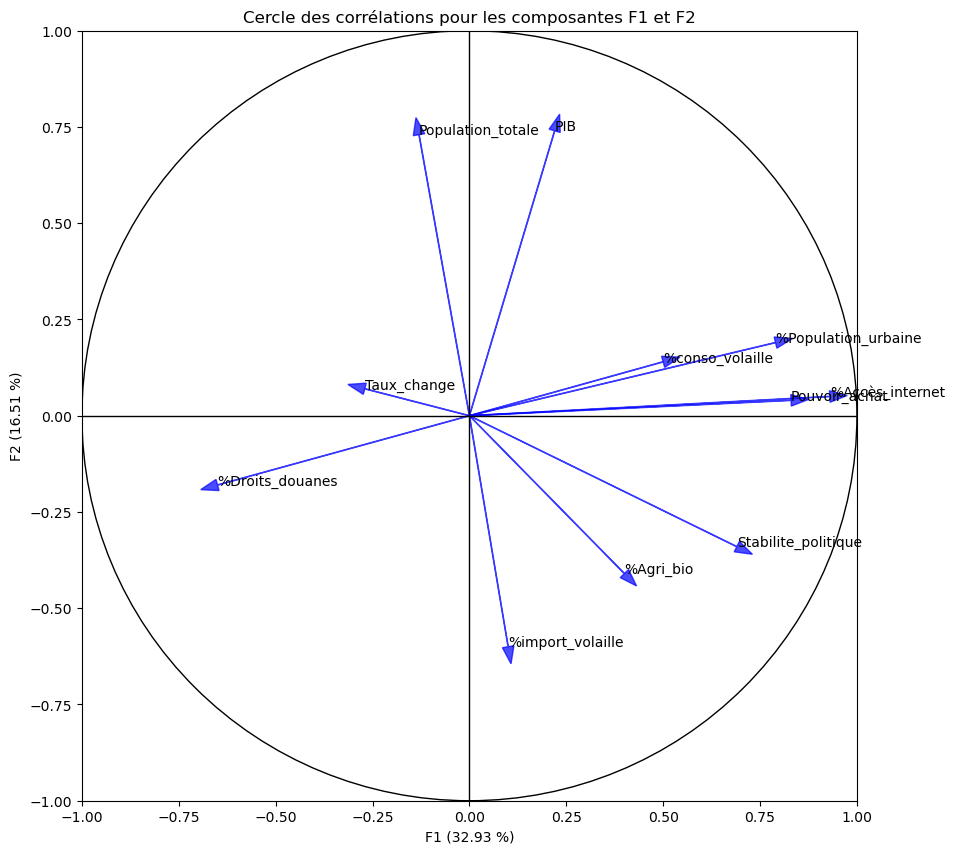

In [14]:
# Création du cercle de corrélation en utilisant les composantes 1 et 2

plt.figure(figsize = (10, 10))                                                 # crée la figure et ajuste la taille
plt.xlim(-1, 1)                                                                # applique des limites aux axes des abscisses (x, horizontal) et ordonnées (y, vertical) pour obtenir un cercle de rayon 1
plt.ylim(-1, 1)
for var in range (p) :                                                         # pour chaque variables (p) :            
    x = correlations_var.iloc[var, 1]                                          # récupère la valeur de correlation correspondante à la composante F1 pour l'axe des abscisses (x, horizontal)           (indice 0 = colonne contenant le nom des variables)
    y = correlations_var.iloc[var, 2]                                          # récupère la valeur de correlation correspondante à la composante F2 pour l'axe des ordonnées (y, vertical)
    plt.arrow(0, 0, x, y, color = "blue", alpha = 0.7, head_width = 0.03)      # trace la flèche représentant le vecteur de la variable
    plt.annotate(datas.columns[var], (x, y))                                   # ajoute l'étiquette de la donnée (nom de la variable)
plt.plot([-1, 1], [0, 0], color = "black", linewidth = 1)                      # trace l'axe des abscisses (x, horizontal)
plt.plot([0, 0], [-1, 1], color = "black", linewidth = 1)                      # trace l'axe des ordonnées (y, vertical)
cercle = plt.Circle((0, 0), 1, color = "black", fill = False)                  # crée le cercle ayant pour centre 0 et de rayon 1
plt.gca().add_artist(cercle)                                                   # trace le cercle sur le graphique courant (gca)
plt.title("Cercle des corrélations pour les composantes F1 et F2")             # ajoutent un titre au graphique et aux axes
plt.xlabel(f"F1 ({inerties[0].round(2)} %)")                                   
plt.ylabel(f"F2 ({inerties[1].round(2)} %)")
plt.show()                                                                     # affiche le graphique final


<div style="border: 1px solid RGB(0,100,0);" >
<h4 style="margin: auto; padding: 20px; color: RGB(189,230,182); ">Plan 2</h4>
</div>

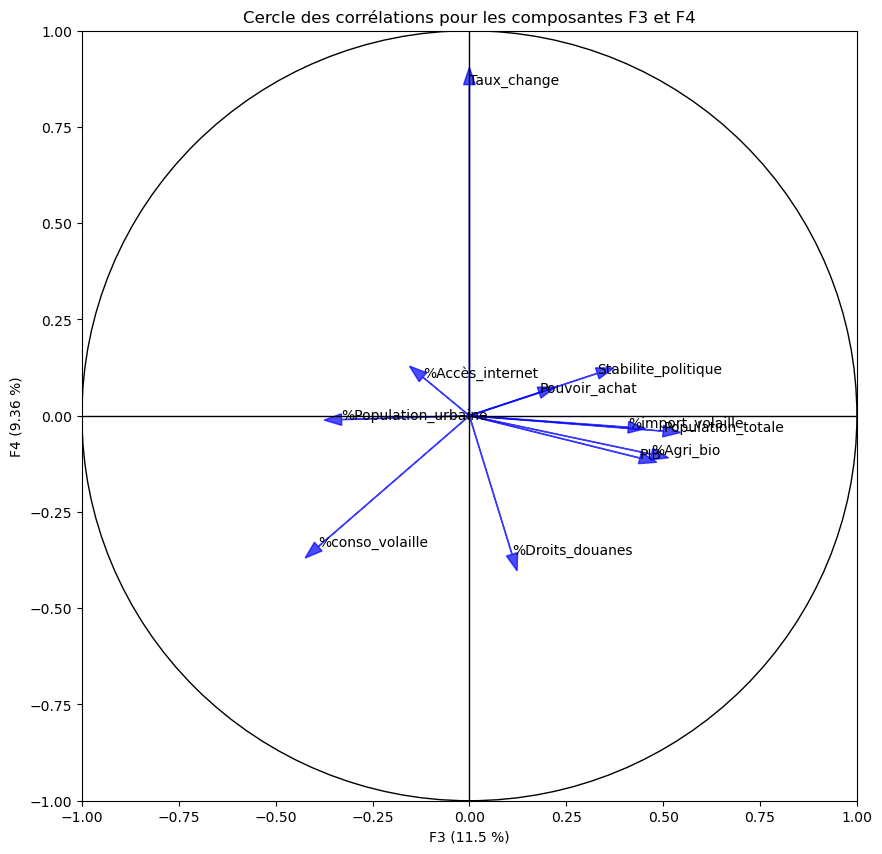

In [15]:
# Création du cercle de corrélation en utilisant les composantes 3 et 4

plt.figure(figsize = (10, 10))                                                 # crée la figure et ajuste la taille
plt.xlim(-1, 1)                                                                # applique des limites aux axes des abscisses (x, horizontal) et ordonnées (y, vertical) pour obtenir un cercle de rayon 1
plt.ylim(-1, 1)
for var in range (p) :                                                         # pour chaque variables (p) :            
    x = correlations_var.iloc[var, 3]                                          # récupère la valeur de correlation correspondante à la composante F3 pour l'axe des abscisses (x, horizontal)           (indice 0 = colonne contenant le nom des variables)
    y = correlations_var.iloc[var, 4]                                          # récupère la valeur de correlation correspondante à la composante F4 pour l'axe des ordonnées (y, vertical)
    plt.arrow(0, 0, x, y, color = "blue", alpha = 0.7, head_width = 0.03)      # trace la flèche représentant le vecteur de la variable
    plt.annotate(datas.columns[var], (x, y))                                   # ajoute l'étiquette de la donnée (nom de la variable)
plt.plot([-1, 1], [0, 0], color = "black", linewidth = 1)                      # trace l'axe des abscisses (x, horizontal)
plt.plot([0, 0], [-1, 1], color = "black", linewidth = 1)                      # trace l'axe des ordonnées (y, vertical)
cercle = plt.Circle((0, 0), 1, color = "black", fill = False)                  # crée le cercle ayant pour centre 0 et de rayon 1
plt.gca().add_artist(cercle)                                                   # trace le cercle sur le graphique courant (gca)
plt.title("Cercle des corrélations pour les composantes F3 et F4")             # ajoutent un titre au graphique et aux axes
plt.xlabel(f"F3 ({inerties[2].round(2)} %)")                                   
plt.ylabel(f"F4 ({inerties[3].round(2)} %)")
plt.show()                                                                     # affiche le graphique final


<div style="border: 1px solid RGB(0,100,0);" >
<h4 style="margin: auto; padding: 20px; color: RGB(189,230,182); ">Plan 3</h4>
</div>

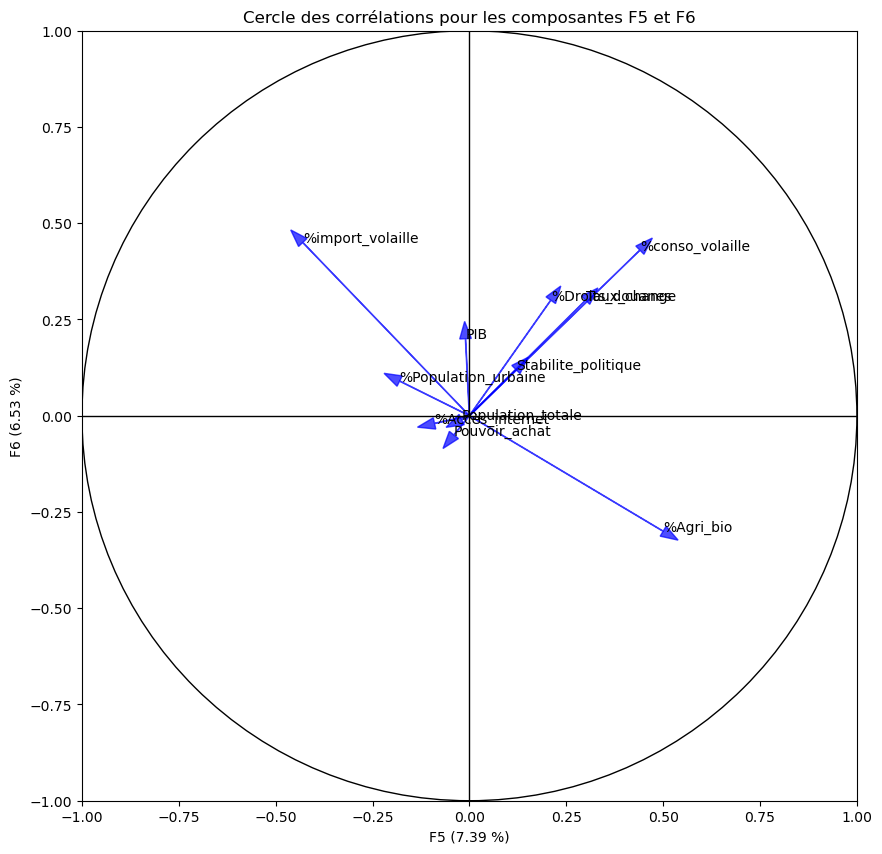

In [16]:
# Création du cercle de corrélation en utilisant les composantes 5 et 6

plt.figure(figsize = (10, 10))                                                 # crée la figure et ajuste la taille
plt.xlim(-1, 1)                                                                # applique des limites aux axes des abscisses (x, horizontal) et ordonnées (y, vertical) pour obtenir un cercle de rayon 1
plt.ylim(-1, 1)
for var in range (p) :                                                         # pour chaque variables (p) :            
    x = correlations_var.iloc[var, 5]                                          # récupère la valeur de correlation correspondante à la composante F5 pour l'axe des abscisses (x, horizontal)           (indice 0 = colonne contenant le nom des variables)
    y = correlations_var.iloc[var, 6]                                          # récupère la valeur de correlation correspondante à la composante F6 pour l'axe des ordonnées (y, vertical)
    plt.arrow(0, 0, x, y, color = "blue", alpha = 0.7, head_width = 0.03)      # trace la flèche représentant le vecteur de la variable
    plt.annotate(datas.columns[var], (x, y))                                   # ajoute l'étiquette de la donnée (nom de la variable)
plt.plot([-1, 1], [0, 0], color = "black", linewidth = 1)                      # trace l'axe des abscisses (x, horizontal)
plt.plot([0, 0], [-1, 1], color = "black", linewidth = 1)                      # trace l'axe des ordonnées (y, vertical)
cercle = plt.Circle((0, 0), 1, color = "black", fill = False)                  # crée le cercle ayant pour centre 0 et de rayon 1
plt.gca().add_artist(cercle)                                                   # trace le cercle sur le graphique courant (gca)
plt.title("Cercle des corrélations pour les composantes F5 et F6")             # ajoutent un titre au graphique et aux axes
plt.xlabel(f"F5 ({inerties[4].round(2)} %)")                                   
plt.ylabel(f"F6 ({inerties[5].round(2)} %)")
plt.show()                                                                     # affiche le graphique final


<div style="border: 1px solid RGB(0,100,0);" >
<h4 style="margin: auto; padding: 20px; color: RGB(189,230,182); ">Interprétation des cercles</h4>
</div>

In [17]:
# Interprétation

## Composante F1 :
    ## Les variables les mieux représentées (flèches longues) sur l'axe F1 sont : %_accès_internet (0.86), pouvoir_achat (0.69), %_population_urbaine (0.62), stabilite_politique (0.48) et %_droits_douanes (0.42).
    ## Ce sont également les variables qui contribuent le plus à cet axe (0.24, 0.19, 0.17, 0.13, 0.11).
    ## Parmi ces variables, il y a une corrélation forte (proche de l'axe, sens positif) avec %_accès_internet (0.93), pouvoir_achat (0.83), %_population_urbaine (0.79) et stabilite_politique (0.69) et une anti-correlation forte (négatif) avec %_droits_douanes (-0.65).
    ## Ceci semble suggèrer que plus un pays est développé/modernisé (urbanisation, accès à internet facile, pouvoir d'achat des habitants élevé), plus il sera ouvert au marché international / moins protectionniste (droits de douanes faibles).
    ## F1 représente donc le niveau de développement socio-économique du pays (développé/modernisé ou non) et sa politique commerciale (ouvert au marché international ou protectionniste).

## Composante F2 :
    ## Les variables les mieux représentées sur l'axe F2 sont : PIB (0.55), population_totale (0.53) et %import_volaille (0.36).
    ## Ce sont également les variables qui contribuent le plus à cet axe (0.30, 0.29, 0.20).
    ## Parmi ces variables, il y a une corrélation forte avec PIB (0.74) et population_totale (0.73) et une anti-correlation forte avec %import_volaille (-0.60).
    ## Ceci semble suggérer que plus un pays est peuplé et riche (population totale et PIB élevés), plus il sera en capacité de produire lui-même et moins enclin à importer (% importation de volaille faible).
    ## F2 représente donc le comportement commercial du pays (importateur ou non) selon son niveau de richesse.

## Composante F3 :
    ## Les variables les mieux représentées sur l'axe F3 sont : population_totale (0.25), %agri_bio (0.22), PIB (0.19), %import_volaille (0.17) et %conso_volaille (0.15).
    ## Ce sont également les variables qui contribuent le plus à cet axe (0.19, 0.17, 0.15, 0.17, 0.15).
    ## Parmi ces variables, il y a une corrélation forte avec population_totale (0.50), %agri_bio (0.47), PIB (0.44) et %import_volaille (0.41) et une anti-correlation forte avec %conso_volaille (-0.39).
    ## Ceci semble suggérer que plus un pays est peuplé et riche, plus il sera propice à importer de la viande volaille et pratiquer l'agriculture biologique, mais ne consommera pas forcément beaucoup de viande de volaille (capable d'acheter des viandes plus chères ?)
    ## F3 représente donc le comportement alimentaire du pays (consommateur ou non + interessé par le bio ou non) selon son niveau de richesse.

## Composante F4 :
    ## Les variables les mieux représentées sur l'axe F4 sont : taux_change (0.74), %droits_douanes (0.13) et %conso_volaille (0.12).
    ## Ce sont également les variables qui contribuent le plus à cet axe (0.72, 0.13, 0.11).
    ## Parmi ces variables, il y a une corrélation forte avec taux_change (0.86) et une anti-correlation forte avec %droits_douanes (-0.36) et %conso_volaille (-0.34).
    ## Ceci semble suggérer que plus le taux de change est faible, plus les droits de douanes seront élevés (protectionnisme) et la consommation de volaille augmente (viande - chère).
    ## F4 rajoute donc uniquement la composante concernant la variation du taux de change, suggérant que si un pays est pauvre (monnaie dépréciée), il consommera plus de viande de volaille et aura recours au protectionnisme pour son économie.
    ## F4 représente donc le comportement commercial et alimentaire du pays selon la valeur de sa monnaie.

## Composante F5 :
    ## Les variables les mieux représentées sur l'axe F5 sont : %agri_bio (0.25), %conso_volaille (0.19) et %import_volaille (0.19).
    ## Ce sont également les variables qui contribuent le plus à cet axe (0.30, 0.24, 0.23).
    ## Parmi ces variables, il y a une corrélation forte avec %agri_bio (0.50) et %conso_volaille (0.44) et une anti-correlation forte avec %import_volaille (-0.43).
    ## Ceci semble suggérer que les pays qui consomment le plus de volaille mais en importe peu, pratiquent également l'agriculture biologique. 
    ## F6 représente donc la politique agricole du pays, notamment vis à vis du bio, en fonction de sa consommation et importation de viande de volaille. (pays producteurs et pratiquants)

## Composante F6 :
    ## Les variables les mieux représentées sur l'axe F6 sont : %import_volaille (0.20) et %conso_volaille (0.19). 
    ## Ce sont également les variables qui contribuent le plus à cet axe (0.28 et 0.26).
    ## Il y a une corrélation forte avec les 2 variables (0.45 et 0.43) mais une anti-corrélation avec %agri_bio (-0.30, contribue également mais très mal représentée)
    ## Ceci semble suggérer que les pays qui consomment et importent beaucoup de volaille, ne pratiquent pas ou moins l'agriculture biologique.
    ## F6 représente donc également la politique agricole du pays, notamment vis à vis du bio, en fonction de sa consommation et importation de viande de volaille. (pays importateurs et non pratiquants)


In [18]:

## Toutes les variables sont déjà bien représentées (>= 0.5) et contribuent aux 4 premières composantes (F1, F2, F3, F4), sauf %conso_volaille et %agri_bio qui sont mieux représentées si on ajoute les composantes F5 et F6 (auxquelles elles contribuent mieux également).

## Les composantes F5 et F6 semblent apporter une information supplémentaire et plus précise sur la pratique du pays en rapport l'agriculture biologique en fonction de sa consommation et importation de viande de volaille.
## Cependant, nous avons déjà accès à cette information de manière un peu plus globale dans les composantes F1 à F4 (consommation de viande de volaille, taux d'importation, pratique du bio en fonction de la taille et de la richesse du pays).
## Pour l'objectif de notre analyse, cela semble pour le moment suffisant.
## D'autre part, la structure du plan F5-F6 est difficilement interprétable car beaucoup de variables sont mal représentées (proches de l'origine). De plus, les 2 axes apportent la même information. Suggérant donc qu'il faut être vigilant avec l'inteprétation de ce plan.
## Il n'est donc finalement pas nécessaire et peut être plus prudent de ne pas conserver les composantes F5 et F6 pour le reste de l'analyse et le clustering.


<div style="border: 1px solid RGB(0,100,0);" >
<h3 style="margin: auto; padding: 20px; color: RGB(189,230,182); ">Projection des données</h3>
</div>

<div style="border: 1px solid RGB(0,100,0);" >
<h4 style="margin: auto; padding: 20px; color: RGB(189,230,182); ">Qualité de représentation des individus</h4>
</div>

In [19]:
# Calcul de la qualité de représentation de chaque individu pour chaque composante principale de l'ACP  (plus valeur élevée = individu bien représenté, proche de 0 = individu peu représenté)

inertie_totale_ind_i = np.sum(datas_scaled**2, axis =1)                                          # calcule l'inertie totale des individus à partir de leurs données initiales
qualite_ind = datas_acp**2                                                                       # calcule la position de chaque individu par rapport aux différentes composantes/axes (inertie captée)

qualites_ind = pd.DataFrame({"" : datas.index})                                                  # crée un dataframe/tableau dans lequel on pourra stocker les résultats de la qualité de représentation des individus dans les composantes principales
for composante in range(p) :                                                                     # pour chaque composante de l'ACP (p) :      
    qualite_ind[:, composante] = (qualite_ind[:, composante] / inertie_totale_ind_i).round(3)    # calcule la qualité de représentation de chaque individu en normalisant son inertie captée par son inertie totale initiale , arrondie à 3 chiffres après la virgule
    nom_colonne = f"F{composante + 1}"                                                           # crée le nom de la nouvelle colonne à ajouter au tableau (nom de la composante principale)
    qualites_ind[nom_colonne] = qualite_ind[:, composante]                                       # ajoute les résultats de la qualité de représentation dans la colonne associée

qualites_ind                                                                                     # affiche le tableau de la qualité de représentation de chaque individu


,,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11
0,ALBANIE,0.011,0.112,0.000,0.072,0.481,0.007,0.187,0.082,0.002,0.044,0.001
1,ALGÉRIE,0.471,0.035,0.091,0.024,0.023,0.053,0.175,0.060,0.020,0.047,0.000
2,ALLEMAGNE,0.622,0.036,0.203,0.004,0.010,0.014,0.056,0.003,0.052,0.000,0.000
3,ARABIE SAOUDITE,0.178,0.043,0.287,0.097,0.019,0.209,0.026,0.058,0.002,0.058,0.022
4,ARGENTINE,0.100,0.055,0.291,0.141,0.140,0.076,0.017,0.017,0.096,0.067,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...
96,TURQUIE,0.104,0.221,0.221,0.009,0.031,0.116,0.000,0.261,0.034,0.001,0.001
97,UKRAINE,0.158,0.114,0.295,0.005,0.036,0.090,0.048,0.195,0.054,0.005,0.000
98,URUGUAY,0.169,0.064,0.018,0.000,0.058,0.133,0.086,0.023,0.126,0.305,0.017
99,VANUATU,0.227,0.378,0.287,0.019,0.000,0.032,0.022,0.027,0.008,0.001,0.000


In [20]:
# Transformation pour avoir la qualité de représentation de l'individu sur chaque plan (proche de 1 = individu bien représenté et interprétable, proche de 0 = mal représenté et non interprétable)

qualites_ind["F1-F2"] = qualites_ind["F1"] + qualites_ind["F2"]       # calcule la qualité de représentation totale des individus sur le plan F1-F2
qualites_ind["F3-F4"] = qualites_ind["F3"] + qualites_ind["F4"]       # calcule la qualité de représentation totale des individus sur le plan F3-F4
qualites_ind["F5-F6"] = qualites_ind["F5"] + qualites_ind["F6"]       # calcule la qualité de représentation totale des individus sur le plan F5-F6
qualites_ind_plan = qualites_ind.iloc[:, [0,12,13,14]]                # récupère les colonnes index et qualités de représentation sur les plans dans un nouveau dataframe
qualites_ind_plan                                                     # affiche le nouveau tableau


,,F1-F2,F3-F4,F5-F6
0,ALBANIE,0.123,0.072,0.488
1,ALGÉRIE,0.506,0.115,0.076
2,ALLEMAGNE,0.658,0.207,0.024
3,ARABIE SAOUDITE,0.221,0.384,0.228
4,ARGENTINE,0.155,0.432,0.216
...,...,...,...,...
96,TURQUIE,0.325,0.230,0.147
97,UKRAINE,0.272,0.300,0.126
98,URUGUAY,0.233,0.018,0.191
99,VANUATU,0.605,0.306,0.032


<div style="border: 1px solid RGB(0,100,0);" >
<h4 style="margin: auto; padding: 20px; color: RGB(189,230,182); ">Contribution des individus</h4>
</div>

In [21]:
# Calcul de la contribution de chaque variable dans chaque composante principale de l'ACP  (proche de 1 = contribue à la composante, proche de 0 = ne contribue pas à la composante)
 
contribution_ind = datas_acp**2                                                                                    # calcule la contribution de chaque individu dans chaque composante/axe (= idem inertie captée)

contributions_ind = pd.DataFrame({"" : datas.index})                                                               # crée un dataframe/tableau dans lequel on pourra stocker les résultats de la contribution des individus dans les composantes principales
for composante in  range(p) :                                                                                      # pour chaque composante de l'ACP (p) :    
    contribution_ind[:, composante] = (contribution_ind[:, composante] / (n * val_propres[composante])).round(3)   # calcule la contribution de chaque individu dans la composante principale associée en normalisant sa contribution individuelle par sa valeur propre
    nom_colonne = f"F{composante + 1}"                                                                             # crée le nom de la nouvelle colonne à ajouter au tableau (nom de la composante principale)
    contributions_ind[nom_colonne] = contribution_ind[:, composante]                                               # ajoute les résultats dans la colonne associée

contributions_ind                                                                                                  # affiche le tableau de la contribution de chaque individu dans les composantes principales de l'ACP


,,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11
0,ALBANIE,0.000,0.002,0.000,0.002,0.019,0.000,0.010,0.006,0.000,0.006,0.000
1,ALGÉRIE,0.008,0.001,0.004,0.001,0.002,0.005,0.019,0.009,0.003,0.012,0.000
2,ALLEMAGNE,0.011,0.001,0.010,0.000,0.001,0.001,0.006,0.000,0.009,0.000,0.000
3,ARABIE SAOUDITE,0.006,0.003,0.027,0.011,0.003,0.034,0.005,0.017,0.001,0.028,0.020
4,ARGENTINE,0.002,0.002,0.014,0.008,0.010,0.006,0.002,0.002,0.015,0.016,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...
96,TURQUIE,0.002,0.008,0.012,0.001,0.003,0.011,0.000,0.044,0.006,0.000,0.001
97,UKRAINE,0.003,0.005,0.018,0.000,0.003,0.010,0.006,0.036,0.011,0.002,0.000
98,URUGUAY,0.004,0.003,0.001,0.000,0.006,0.015,0.012,0.004,0.027,0.101,0.011
99,VANUATU,0.007,0.024,0.026,0.002,0.000,0.005,0.005,0.008,0.002,0.000,0.000


<div style="border: 1px solid RGB(0,100,0);" >
<h4 style="margin: auto; padding: 20px; color: RGB(189,230,182); ">Plan 1</h4>
</div>

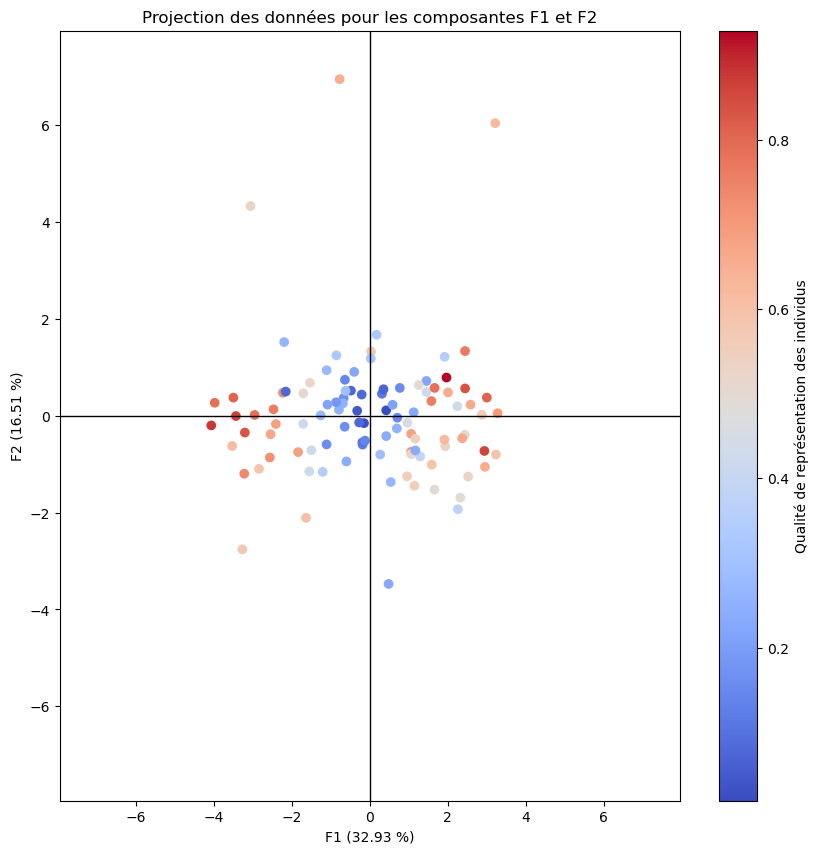

In [22]:
# Projection des données sur le plan contenant les composantes 1 et 2

plt.figure(figsize = (10, 10))                                                 # crée la figure et ajuste la taille
x = datas_acp[:, 0]                                                            # récupère les coordonnées de chaque individu correspondant à la composante F1 pour l'axe des abscisses (x, horizontal)          
y = datas_acp[:, 1]                                                            # récupère les coordonnées de chaque individu correspondant à la composante F2 pour l'axe des ordonnées (y, vertical)
qualite = qualites_ind_plan["F1-F2"]                                           # récupère la valeur de qualité de représentation des individus sur le plan 
lim = max(max(np.abs(x)), max(np.abs(y))) + 1                                  # récupèrent la valeur maximale pour les coordonnées sur les axes des abscisses (x, horizontal) et ordonnées (y, vertical)
plt.xlim(-lim, lim)                                                            # appliquent les limites aux axes des abscisses (x, horizontal) et ordonnées (y, vertical)
plt.ylim(-lim, lim)
nuage = plt.scatter(x, y, c = qualite, cmap = "coolwarm")                      # crée le nuage des individus (nuage de points), affiche la couleur en fonction de la qualité de représentation de l'individu (bleu = mal représenté, rouge = bien représenté)
color_bar = plt.colorbar(nuage)                                                # ajoute une légende pour comprendre les couleurs observées sur le graphique
color_bar.set_label("Qualité de représentation des individus")                 # ajoute un titre à la légende
plt.plot([-lim, lim], [0, 0], color = "black", linewidth = 1)                  # trace l'axe des abscisses (x, horizontal)
plt.plot([0, 0], [-lim, lim], color = "black", linewidth = 1)                  # trace l'axe des ordonnées (y, vertical)
plt.title("Projection des données pour les composantes F1 et F2")              # ajoutent un titre au graphique et aux axes
plt.xlabel(f"F1 ({inerties[0].round(2)} %)")                                   
plt.ylabel(f"F2 ({inerties[1].round(2)} %)")
plt.show()                                                                     # affiche le graphique final


<div style="border: 1px solid RGB(0,100,0);" >
<h4 style="margin: auto; padding: 20px; color: RGB(189,230,182); ">Plan 2</h4>
</div>

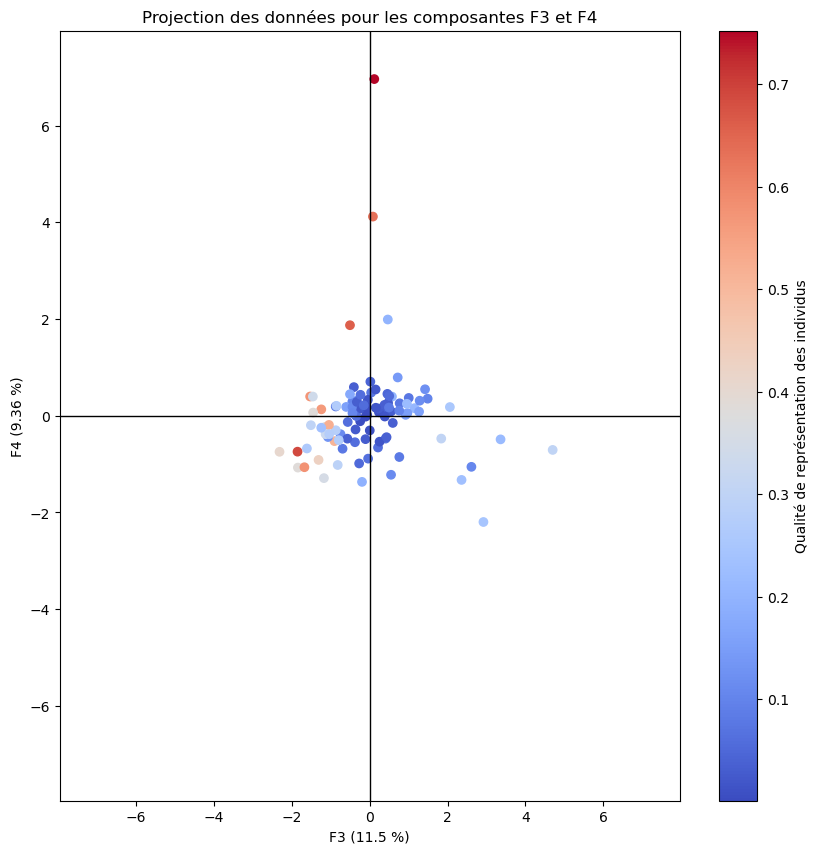

In [23]:
# Projection des données sur le plan contenant les composantes 3 et 4

plt.figure(figsize = (10, 10))                                                 # crée la figure et ajuste la taille
x = datas_acp[:, 2]                                                            # récupère les coordonnées de chaque individu correspondant à la composante F3 pour l'axe des abscisses (x, horizontal)          
y = datas_acp[:, 3]                                                            # récupère les coordonnées de chaque individu correspondant à la composante F4 pour l'axe des ordonnées (y, vertical)
qualite = qualites_ind_plan["F3-F4"]                                           # récupère la valeur de qualité de représentation des individus sur le plan 
lim = max(max(np.abs(x)), max(np.abs(y))) + 1                                  # récupèrent la valeur maximale pour les coordonnées sur les axes des abscisses (x, horizontal) et ordonnées (y, vertical)
plt.xlim(-lim, lim)                                                            # appliquent les limites aux axes des abscisses (x, horizontal) et ordonnées (y, vertical)
plt.ylim(-lim, lim)
nuage = plt.scatter(x, y, c = qualite, cmap = "coolwarm")                      # crée le nuage des individus (nuage de points), affiche la couleur en fonction de la qualité de représentation de l'individu (bleu = mal représenté, rouge = bien représenté)
color_bar = plt.colorbar(nuage)                                                # ajoute une légende pour comprendre les couleurs observées sur le graphique
color_bar.set_label("Qualité de représentation des individus")                 # ajoute un titre à la légende
plt.plot([-lim, lim], [0, 0], color = "black", linewidth = 1)                  # trace l'axe des abscisses (x, horizontal)
plt.plot([0, 0], [-lim, lim], color = "black", linewidth = 1)                  # trace l'axe des ordonnées (y, vertical)
plt.title("Projection des données pour les composantes F3 et F4")              # ajoutent un titre au graphique et aux axes
plt.xlabel(f"F3 ({inerties[2].round(2)} %)")                                   
plt.ylabel(f"F4 ({inerties[3].round(2)} %)")
plt.show()                                                                     # affiche le graphique final


<div style="border: 1px solid RGB(0,100,0);" >
<h4 style="margin: auto; padding: 20px; color: RGB(189,230,182); ">Interprétation des projections</h4>
</div>

In [24]:
# Interprétation

## La représentation des individus sur le plan F1-F2 peut être considérée optimale car le nuage de point est bien étalé (= les points sont bien séparés). L'inertie est donc maximale avec 49,44% de représentation (32.93 + 16.51).
## Ce n'est pas le cas pour le plan F3-F4 puisque la majorité des individus sont situés au centre (= points regroupés, peu séparés, sauf quelques exceptions). L'inertie totale du plan est de 20.86% (11.50 + 9.36). Cela est normal car le plan F1-F2 constitue
## le plan principal (contenant les informations principales et expliquant la plus grande part de variance), alors que le plan F3-F4 est secondaire et vient s'ajouter au plan F1-F2 pour apporter des informations complémentaires uniquement. En ajoutant les
## inerties des 2 plans, nous obtenons 70.30 % de variance expliquée (70% d'individus bien représentés), ce qui reste convenable pour notre analyse.

## Lorsque les individus d'un groupe sont bien représentés sur le plan, l'interprétation peut être considérée comme fiable. Dans le cas contraire, il est préférable de passer au plan suivant pour voir s'ils sont mieux représentés et si une information peut en être tirée.

## Si nous continuons sur le plan F1-F2, à 1ère vue il n'est pas évident de séparer des groupes d'individus car le nuage est essentiellement regroupé au centre des axes (sauf 6 points, 3 en haut et 3 en bas) mais en associant la couleur correspondant à la qualité de 
## représentation des indivus sur le plan, 4 groupes (clusters) semblent finalement se séparer : 1 central avec des individus mal représentés qui ne contribuent pas à la formation des axes F1 et F2, 1 à l'extrémité positive de l'axe F2 avec des individus bien représentés
## et qui contribuent à la formation cet axe, et enfin 2 groupes situés de chaque côté sur l'axe F1 contenant les individus les mieux représentés et qui contribuent le plus à la formation cet axe.
## Si nous essayons d'analyser le profil de ces groupes :
    ## le groupe situé à l'extrémité positive de l'axe F2 pourrait constituer un groupe de pays peuplés et riches (pop_totale et PIB élevés) mais non importateurs (%import_volaille faible). Ce groupe étant très séparé des autres, il semble aussi constituer des outliers.
    ## le groupe situé au centre n'est pas interprétable sur ce plan car ses individus sont mal représentés donc il faudra voir si nous obtenons des informations supplémentaires avec le plan F3-F4.
    ## le groupe situé du coté négatif de l'axe F1 pourrait constituer un groupe de pays peu développés et modernisés (pop_urbaine, accès_internet, pouvoir_achat faibles) et du coup protectionnistes pour leur économie (%droits_douanes élevés, ne facilite pas l'import).
    ## au contraire, le groupe situé du côté positif de l'axe F1 pourrait constituer un groupe de pays développés et modernisés (pop_urbaine, accès_internet, pouvoir_achat élevés) et du coup ouvert au commerce international (%droits_douanes faible, facilite l'import).
## Le quart en haut à droite de ce plan représente donc des individus/pays riches, peuplés, développés, modernisés et ouverts au commerce international mais pas importeurs.
## Le quart en haut à gauche du plan représente des individus/pays riches et peuplés, mais peu développés, ni modernisés et du coup protectionnistes et non importeurs.
## Le quart en bas à gauche du plan représente des individus/pays pauvres et peu peuplés, peu développés, ni modernisés (économie instable) et du coup protectionnistes (barrières commerciales) mais importeurs.
## Le quart en bas à droite du plan représente des individus/pays pauvres et peu peuplés, mais développés et modernisés et donc ouverts au commerce internationnal et importeurs.


## En ce qui concerne le plan F3-F4, comme pour le plan F1-F2, à 1ère vue il n'est pas évident de séparer des groupes d'individus car le nuage est essentiellement regroupé au centre des axes (sauf 4 points vers le haut, et 5 points dans le quart bas/droite).
## Lorsqu'on associe la couleur correspondant à la représentation des individus sur le plan, 4 groupes (clusters) semblent se séparer : 1 central contenant essentiellement des individus mal représentés et qui ne contribuent pas à la formation des axes F3 et F4
## mais contenant quand même quelques points mieux représentés, 1 groupe constitué des 4 points situés sur le coté positif de l'axe F4 (vers le haut) et dont 2 sont très bien représentés et contribuent à la formation de cet axe, et 1 dernier groupe composé des 
## quelques points situés dans le quart bas/droite du graphique dont 3 semblent contribuer à la formation de l'axe F3 mais mal représentés.
    ## le groupe central n'est pas interprétable sur ce plan car la majorité de ses individus sont mal représentés. Ils étaient peut être interprétables sur l'axe F1-F2, dans ce cas ce n'est pas gênant.
    ## le groupe situé sur le côté positif de l'axe F4 pourrait constituer un groupe de pays plutôt riche (taux de change élevé) et ouvert au commerce international (%droits_douanes faible, facilite l'import).
    ## le groupe situé dans le quart bas/droite pourrait constitué un groupe de pays pauvres et peu développés (pas urbanisé, pas accès internet, taux de change faible), protectionnistes et peu consomateurs de volaille mais importateurs et pratiquant l'agriculture bio.
## Le quart en haut à droite du ce plan représente donc des individus/pays aisés (taux de change élevé) qui appliquent des droits de douanes faibles (facilite l'importation) mais consomment peu de viande de volaille et pratiquent l'agriculture biologique.
## Le quart en haut à gauche du plan représente des individus/pays aisés (taux de change élevé) qui appliquent des droits de douanes faibles (facilite l'importation), consomment de la viande de volaille mais n'importent pas et ne pratiquent pas l'agriculture biologique.
## Le quart en bas à gauche du plan représente des individus/pays plus pauvres (taux de change faible), non importeurs et ne pratiquant pas l'agriculture biologique, mais consommateurs de viande de volaille et protectionnistes (%droits_douanes élevés).
## Le quart en bas à droite du plan représente des individus/pays plus pauvres (taux de change faible), qui importent et consomment de la viande de volaille et pratiquent l'agriculture biologique, mais protectionnistes. 


<div style="background-color: RGB(189,236,182);" >
<h2 style="margin: auto; padding: 20px; color: black; ">CLUSTERING</h2>
</div>

In [25]:
# Création du nouveau dataset à analyser en ne conservant que les composantes principales issues de l'ACP (réduction du nombre de variables)

datas_clust = copy.deepcopy(datas_acp[:, 0:4])      # crée une copie du tableau des coordonnées standardisées pour effectuer le clustering sans compromettre les données intiales, et en ne gardant que les 4 premières colonnes (composantes principales)
datas_clust[0:2, :]                                 # affiche les 2 premières lignes de l'array pour vérifier qu'on a bien gardé que 4 colonnes


array([[-0.18391727, -0.59658388,  0.03455857,  0.4780506 ],
       [-1.7048459 ,  0.46137091, -0.75099859, -0.38201566]])

<div style="border: 1px solid RGB(0,100,0);" >
<h3 style="margin: auto; padding: 20px; color: RGB(189,230,182); ">Classification Ascendante Hierarchique</h3>
</div>

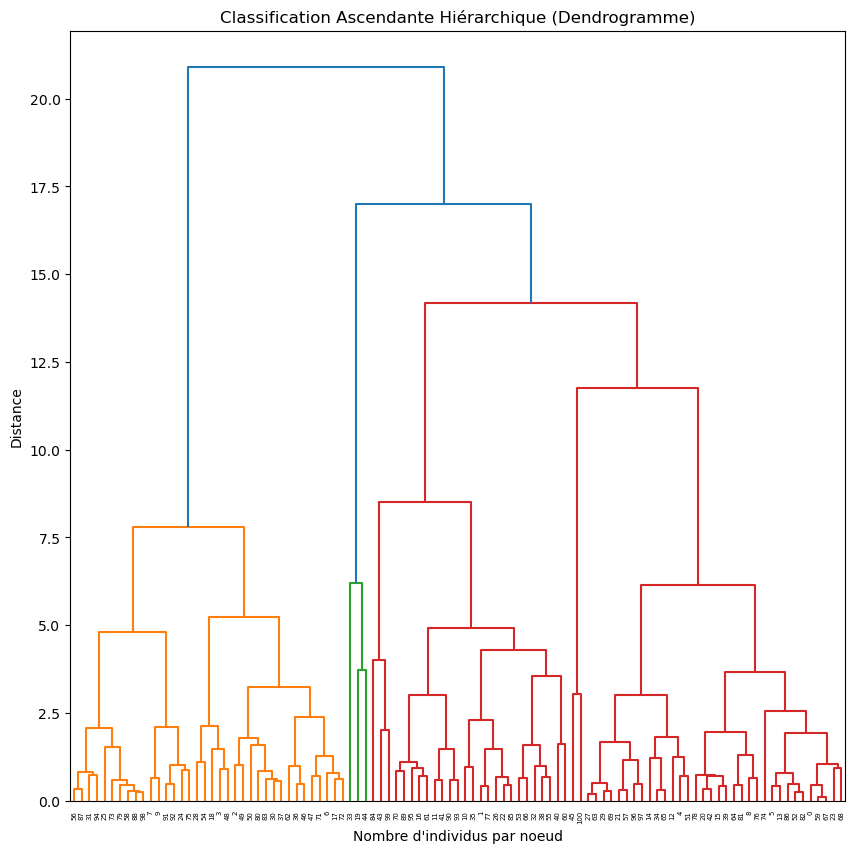

In [26]:
# Application de la CAH sur les données corrigées après l'ACP (calcul des distances de fusion et création du dendrogramme de visualisation)

from scipy.cluster.hierarchy import dendrogram, linkage

matrix = linkage(datas_clust, method = "ward")                             # utilise la méthode de Ward pour calculer les distances/liens entre chaque cluster à chaque itération (regroupement de 2 clusters à chaque étape avec inertie intraclasse minimale) 

plt.figure(figsize = (10, 10))                                             # ajuste la taille de la figure
dendrogram(matrix)                                                         # crée le dendrogramme (arbre hiérachique), représentant la classification
plt.title("Classification Ascendante Hiérarchique (Dendrogramme)")         # ajoutent des titres au graphique et aux axes des abscisses (x, horizontal) et ordonnées (y, vertical)
plt.xlabel("Nombre d'individus par noeud")  
plt.ylabel("Distance")
plt.show()                                                                 # affiche le graphique


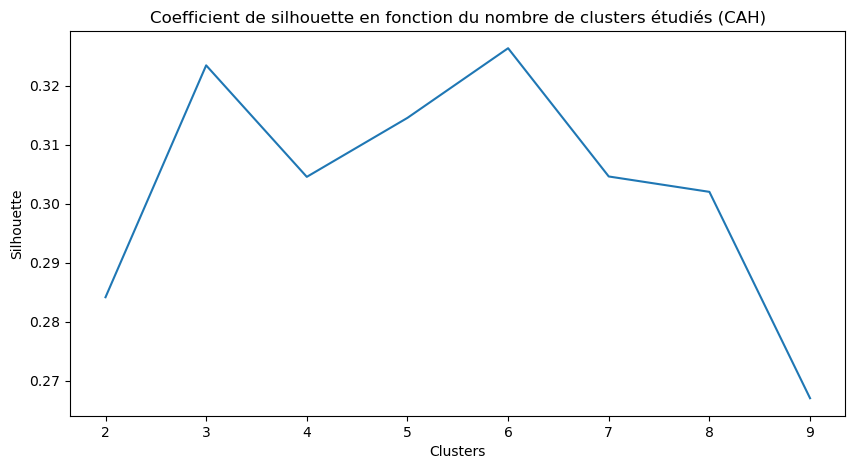

In [27]:
# Choix du nombre de clusters à étudier : utilisation du coefficient de silhouette

from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import fcluster

liste_silhouettes = []                                                                  # crée une liste qui permettra de récupérer et stocker les coefficients de silhouette de chaque itération du clustering
liste_clusters = range(2, 10)                                                           # crée une liste contenant le nombre de clusters à étudier (de k = 2 à k = 10)

for k in liste_clusters :                                                               # crée la boucle qui permet de réaliser le clustering sur chaque nombre de cluster souhaité
    labels = fcluster(matrix, k, criterion = "maxclust")                                # découpe le dendrogramme représenté par matrix pour obtenir k clusters (maxclust), et retourne pour chaque individu le numéro du cluster auquel il appartient (label)
    if len(labels) > 1 :                                                                # vérifie que le nombre de clusters trouvés est bien > 1 (au moins 2 nécessaire pour calculer le score)
        score = silhouette_score(datas_clust, labels)                                   # calcule le coefficient de silhouette (score > 0.5, proche de 1 = clusters bien séparés / < 0.25 = clustering faible / 0.25 - 0.5 = moyen)
        liste_silhouettes.append(score)                                                 # récupère le score obtenu et le stocke dans la liste créée précédemment 
    else:
        liste_silhouettes.append(np.nan)

plt.figure(figsize = (10, 5))                                                           # ajuste la taille du graphique
plt.plot(liste_clusters, liste_silhouettes)                                             # crée la courbe des scores en fonction du nombre de clusters étudiés
plt.xticks(liste_clusters)                                                              # assure que chaque cluster est bien marqué sur l'axe des abscisses (x, horizontal)
plt.title("Coefficient de silhouette en fonction du nombre de clusters étudiés (CAH)")  # ajoutent des titres au graphique et aux axes des abscisses (x, horizontal) et ordonnées (y, vertical)
plt.xlabel("Clusters") 
plt.ylabel("Silhouette")
plt.show()                                                                              # affiche le graphique
    

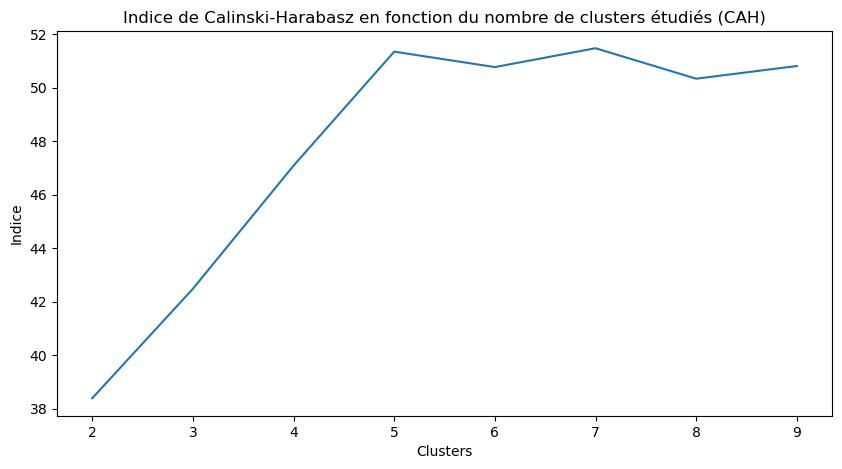

In [28]:
# Choix du nombre de clusters à étudier : utilisation de l'indice de Calinski-Harabasz (plus indice élevé = bonne partition)

from sklearn.metrics import calinski_harabasz_score

liste_indices = []                                                                        # crée une liste qui permettra de récupérer et stocker les indices de chaque itération du clustering
liste_clusters = range(2, 10)                                                             # crée une liste contenant le nombre de clusters à étudier (de k = 2 à k = 10)

for k in liste_clusters :                                                                 # crée la boucle qui permet de réaliser le clustering sur chaque nombre de cluster souhaité
    labels = fcluster(matrix, k, criterion = "maxclust")                                  # découpe le dendrogramme représenté par matrix pour obtenir k clusters (maxclust), et retourne pour chaque individu le numéro du cluster auquel il appartient (label)
    if len(labels) > 1 :                                                                  # vérifie que le nombre de clusters trouvés est bien > 1 (au moins 2 nécessaire pour calculer le score)
        score = calinski_harabasz_score(datas_clust, labels)                              # calcule l'indice de Calinski-Harabasz (= rapport de dispersion inter-cluster / intra-cluster)
        liste_indices.append(score)                                                       # récupère l'indice obtenu et le stocke dans la liste créée précédemment 
    else:
        liste_indices.append(np.nan)

plt.figure(figsize = (10, 5))                                                             # ajuste la taille du graphique
plt.plot(liste_clusters, liste_indices)                                                   # crée la courbe des scores en fonction du nombre de clusters étudiés
plt.xticks(liste_clusters)                                                                # assure que chaque cluster est bien marqué sur l'axe des abscisses (x, horizontal)
plt.title("Indice de Calinski-Harabasz en fonction du nombre de clusters étudiés (CAH)")  # ajoutent des titres au graphique et aux axes des abscisses (x, horizontal) et ordonnées (y, vertical)
plt.xlabel("Clusters") 
plt.ylabel("Indice")
plt.show()                                                                                # affiche le graphique
    

In [29]:
# Choix du nombre de clusters à conserver :

    ## Pour le dendrogramme, chaque barre horizontale représente la fusion de 2 clusters. Nous cherchons donc la 1ère barre horizontale la plus longue (= pour laquelle il a fallu fusionner 2 clusters très éloignés) 
    ## car cela signifie que les 2 groupes sont trop différents et qu'il est mieux de les garder séparés. Pour une classification ascendante, il faut partir du bas (= partir de plusieurs points jusqu'à 1 seul groupe).
    ## Dans notre cas, il y a 2 barres de même taille aux distances ~6 et ~7.5. Si nous coupons le graphique à distance ~6, il reste 7 barres verticales = 7 groupes séparés/clusters. Si nous le coupons à distance ~7.5, il reste 6 barres verticales = 6 groupes/clusters.
    ## Pour nous aider à choisir entre les 2 valeurs, nous allons compléter l'analyse avec le silhouette score et l'indice de Calinski-Harabasz.
    ## Sur le graphique du silhouette score, nous pouvons constater 2 pics (valeurs maximales, ~0.35) pour 3 et 6 clusters.
    ## L'indice de Calinski-Harabasz est lui maximal et se stabilise à partir de 5 clusters. Ce qui suggère de choisir un nombre de clusters >= 5.
    ## En combinant donc le dendrogramme avec les résultats du silhouette score et de l'indice de  Calinski-Harabasz, il paraît donc plus pertinent de conserver 6 clusters à étudier (valeur commune aux 3 indicateurs).


In [30]:
# Application du clustering avec le nombre de clusters optimal choisi précédemment :

from sklearn.cluster import AgglomerativeClustering

cah = AgglomerativeClustering(n_clusters = 6, linkage = "ward")         # utilise la méthode de ward pour estimer les distances entre les clusters et séparer les données en 6 clusters
cah.fit(datas_clust)                                                    # applique la méthode de clustering sur les données corrigées après l'ACP

liste_labels = cah.labels_                                              # récupère la liste des nouveaux labels des individus (= nom/numéro du cluster associé à l'individu)
for k in range(0, 6) :
    nb_individus = len(liste_labels[liste_labels == k])                 # récupère et compte le nombre d'individus présents dans chaque cluster (k)
    print(f"Le cluster {k} contient {nb_individus} individus.") 


Le cluster 0 contient 36 individus.
Le cluster 1 contient 34 individus.
Le cluster 2 contient 3 individus.
Le cluster 3 contient 23 individus.
Le cluster 4 contient 2 individus.
Le cluster 5 contient 3 individus.


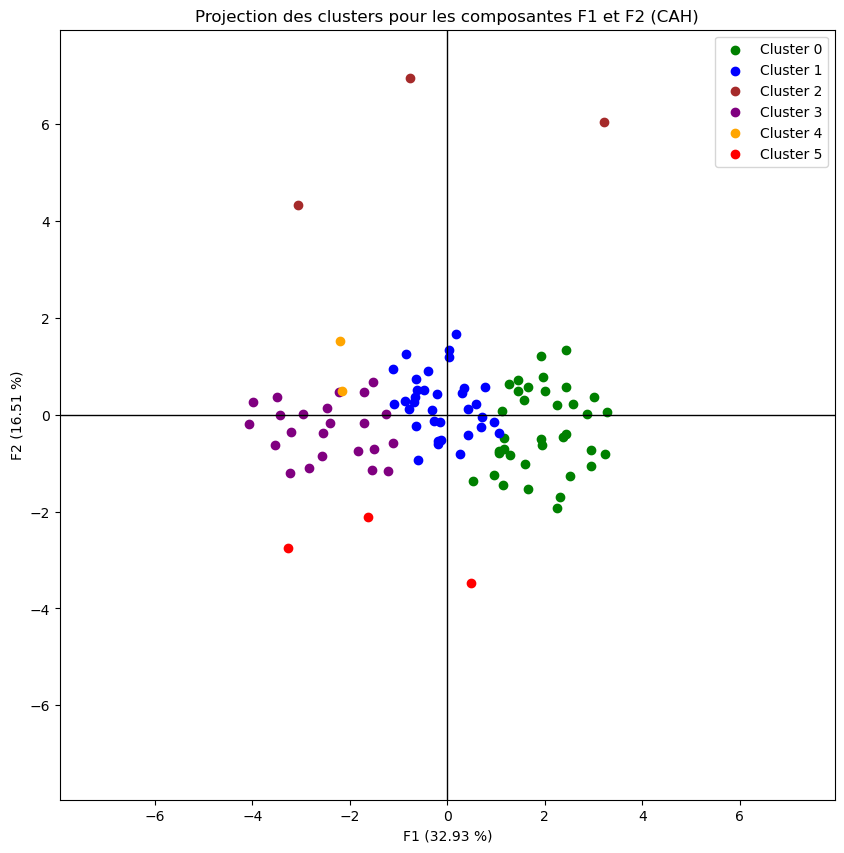

In [31]:
# Affichage des clusters sur les 2 premières composantes de l'ACP

colormap = ["green", "blue", "brown", "purple", "orange", "red"]                       # crée une palette de couleur pour afficher les clusters

x = datas_clust[:, 0]                                                                  # récupère les coordonnées de chaque individu correspondant à la composante F1 pour l'axe des abscisses (x, horizontal)          
y = datas_clust[:, 1]                                                                  # récupère les coordonnées de chaque individu correspondant à la composante F2 pour l'axe des ordonnées (y, vertical)

plt.figure(figsize = (10, 10))                                                         # ajuste la taille du graphique
lim = max(max(np.abs(x)), max(np.abs(y))) + 1                                          # récupèrent la valeur maximale pour les coordonnées sur les axes des abscisses (x, horizontal) et ordonnées (y, vertical)
plt.xlim(-lim, lim)                                                                    # appliquent les limites aux axes des abscisses (x, horizontal) et ordonnées (y, vertical)
plt.ylim(-lim, lim)
for i in range(len(set(cah.labels_))) :                                                # crée le nuage des individus (nuage de points) pour chaque cluster sur les composantes principales F1 et F2
    plt.scatter(x[cah.labels_ == i], y[cah.labels_ == i], color = colormap[i], label = f"Cluster {i}")
plt.plot([-lim, lim], [0, 0], color = "black", linewidth = 1)                          # trace l'axe des abscisses (x, horizontal)
plt.plot([0, 0], [-lim, lim], color = "black", linewidth = 1)                          # trace l'axe des ordonnées (y, vertical)
plt.title("Projection des clusters pour les composantes F1 et F2 (CAH)")               # ajoutent un titre au graphique et aux axes des abscisses (x, horizontal) et ordonnées (y, vertical)
plt.xlabel(f"F1 ({inerties[0].round(2)} %)")                                   
plt.ylabel(f"F2 ({inerties[1].round(2)} %)")
plt.legend()                                                                           # affiche la légende du graphique
plt.show()                                                                             # affiche le graphique final


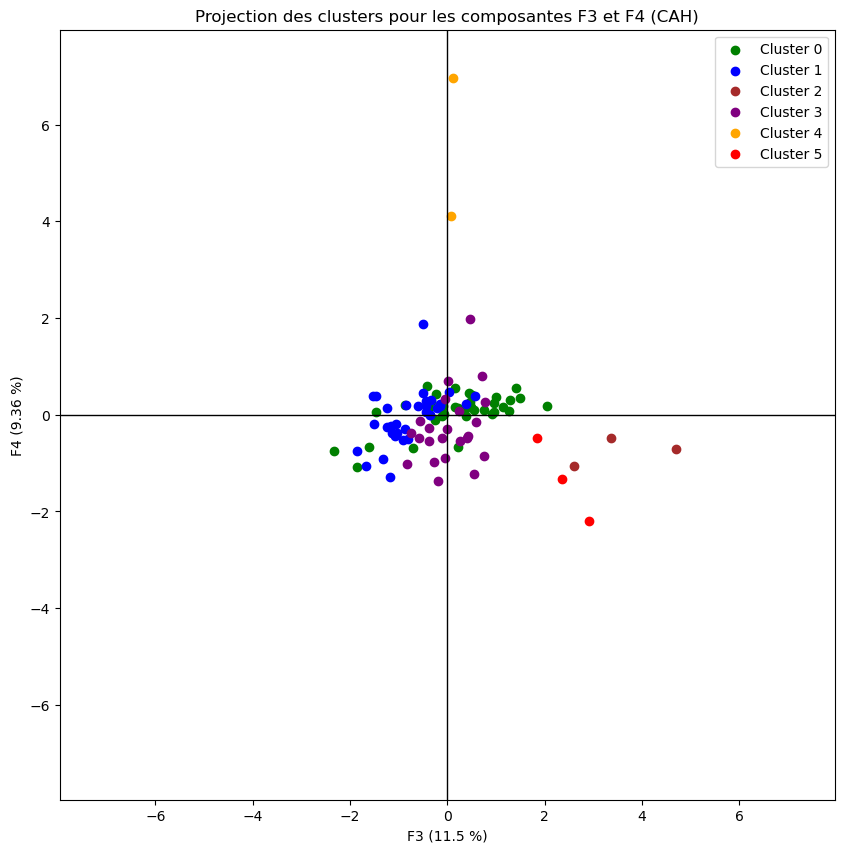

In [32]:
# Affichage des clusters sur les composantes F3 et F4 de l'ACP

colormap = ["green", "blue", "brown", "purple", "orange", "red"]                       # crée une palette de couleur pour afficher les clusters

x = datas_clust[:, 2]                                                                  # récupère les coordonnées de chaque individu correspondant à la composante F3 pour l'axe des abscisses (x, horizontal)          
y = datas_clust[:, 3]                                                                  # récupère les coordonnées de chaque individu correspondant à la composante F4 pour l'axe des ordonnées (y, vertical)

plt.figure(figsize = (10, 10))                                                         # ajuste la taille du graphique
lim = max(max(np.abs(x)), max(np.abs(y))) + 1                                          # récupèrent la valeur maximale pour les coordonnées sur les axes des abscisses (x, horizontal) et ordonnées (y, vertical)
plt.xlim(-lim, lim)                                                                    # appliquent les limites aux axes des abscisses (x, horizontal) et ordonnées (y, vertical)
plt.ylim(-lim, lim)
for i in range(len(set(cah.labels_))) :                                                # crée le nuage des individus (nuage de points) pour chaque cluster sur les composantes principales F3 et F4
    plt.scatter(x[cah.labels_ == i], y[cah.labels_ == i], color = colormap[i], label = f"Cluster {i}")
plt.plot([-lim, lim], [0, 0], color = "black", linewidth = 1)                          # trace l'axe des abscisses (x, horizontal)
plt.plot([0, 0], [-lim, lim], color = "black", linewidth = 1)                          # trace l'axe des ordonnées (y, vertical)
plt.title("Projection des clusters pour les composantes F3 et F4 (CAH)")               # ajoutent un titre au graphique et aux axes des abscisses (x, horizontal) et ordonnées (y, vertical)
plt.xlabel(f"F3 ({inerties[2].round(2)} %)")                                   
plt.ylabel(f"F4 ({inerties[3].round(2)} %)")
plt.legend()                                                                           # affiche la légende du graphique
plt.show()                                                                             # affiche le graphique final


In [33]:
# Ajout de l'information du numéro de cluster associé pour chaque individu dans le tableau des données initiales

datas["Cluster_CAH"] = cah.labels_ 
datas.head()                                  # affiche les 5 premières lignes du tableau pour vérifier que la modification a été apportée et est correcte


,Population_totale,%Population_urbaine,PIB,Pouvoir_achat,Taux_change,%conso_volaille,%import_volaille,%Accès_internet,%Droits_douanes,Stabilite_politique,%Agri_bio,Cluster_CAH
Pays,,,,,,,,,,,,
ALBANIE,2884169.0,60.33,1.301973e+10,4357.51,119.100000,1.29,80.85,62.4000,0.85,0.373771,0.05,1
ALGÉRIE,41389189.0,71.93,1.700970e+11,3584.64,110.973017,0.80,0.76,47.6911,9.38,-0.919614,0.00,3
ALLEMAGNE,82658409.0,76.75,3.763092e+12,44574.38,0.885206,2.06,52.33,84.3942,1.96,0.574381,8.21,0
ARABIE SAOUDITE,33101179.0,83.21,7.149947e+11,23294.86,3.750000,7.93,50.31,94.1756,4.85,-0.649626,0.01,0
ARGENTINE,43937140.0,92.45,6.436284e+11,10397.42,16.562707,5.44,0.43,74.2949,7.93,0.162542,3.04,1


In [34]:
# Conclusion :

cluster_cah = 0                                                       # indication du n° de cluster contenant les pays qui semblent être des bons candidats pour l'exportation de poulet
liste_pays_cah = datas.index[datas["Cluster_CAH"] == cluster_cah]     # récupère la liste des pays présents dans le cluster choisi

print(f"Les pays qui semblent être les meilleurs candidats pour l'exportation des poulets de La Poule qui Chante sont ceux du cluster {cluster_cah}.")
print(f"Ce groupe contient {len(liste_pays_cah)} pays et semble correspondre aux pays développés, modernisés (accès à internet) et ouverts au marché international (F1 positif), de taille et richesse moyenne (en capacité d'acheter, F2 centré),") 
print(f"consommateurs et importateurs moyens de viande de volaille (F2 etF3 centrés) et pas forcément pratiquants de l'agriculture biologique mais pas contres non plus (F4 centré).")
print(f"Liste des pays : {liste_pays_cah}")

# les individus de ce cluster sont également bien représentés sur le plan F1-F2. Leur interprétation est donc fiable sur ce plan (pays riches développés et ouverts).
# En revanche, ils sont moins bien représentés sur le plan F3-F4. L'interprétation de la consommation et importation de volaille et de la pratique de l'agriculture biologique peut être prise en compte mais à modérer.


Les pays qui semblent être les meilleurs candidats pour l'exportation des poulets de La Poule qui Chante sont ceux du cluster 0.
Ce groupe contient 36 pays et semble correspondre aux pays développés, modernisés (accès à internet) et ouverts au marché international (F1 positif), de taille et richesse moyenne (en capacité d'acheter, F2 centré),
consommateurs et importateurs moyens de viande de volaille (F2 etF3 centrés) et pas forcément pratiquants de l'agriculture biologique mais pas contres non plus (F4 centré).
Liste des pays : Index(['ALLEMAGNE', 'ARABIE SAOUDITE', 'AUSTRALIE', 'AUTRICHE', 'BELGIQUE',
       'CANADA', 'CHILI', 'DANEMARK', 'DOMINIQUE', 'ÉMIRATS ARABES UNIS',
       'ESPAGNE', 'ESTONIE', 'FINLANDE', 'FRANCE', 'IRLANDE', 'ISLANDE',
       'ISRAËL', 'ITALIE', 'JAPON', 'KOWEÏT', 'LETTONIE', 'LITUANIE', 'MALTE',
       'NORVÈGE', 'NOUVELLE-ZÉLANDE', 'OMAN', 'PAYS-BAS', 'PORTUGAL',
       'RÉPUBLIQUE DE CORÉE',
       'ROYAUME-UNI DE GRANDE-BRETAGNE ET D'IRLANDE DU NORD', '

In [35]:
# Incovénient de la CAH vs le K-Means :

## La CAH nécessite beaucoup de temps et beaucoup d'espace mémoire car à chaque itération, il faut recalculer les distances de toutes les paires de points possibles entre les 2 clusters en question. 
## => l'algorithme va mettre du temps avant de fournir le résultat. Il sera donc mieux adapté pour les petits échantillons.


<div style="border: 1px solid RGB(0,100,0);" >
<h3 style="margin: auto; padding: 20px; color: RGB(189,230,182); ">K-means</h3>
</div>

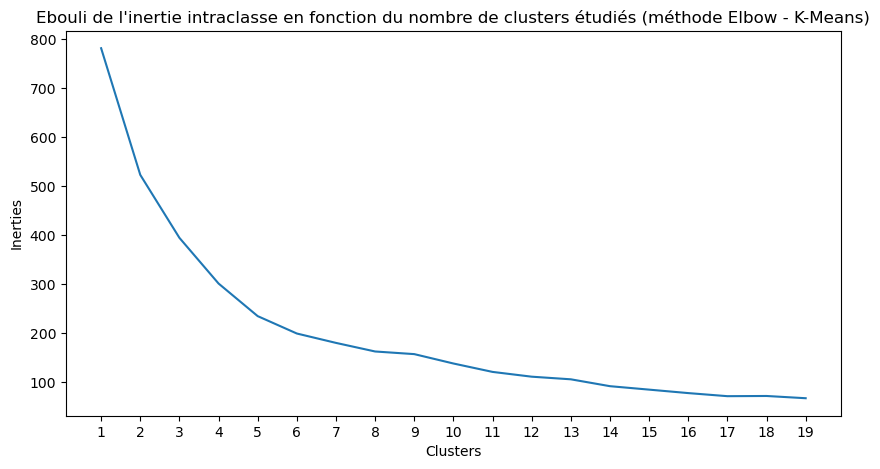

In [36]:
# Choix du nombre de clusters à étudier : utilisation de la méthode du coude (méthode Elbow)

from sklearn.cluster import KMeans

liste_inerties = []                                                                                      # crée une liste qui permettra de récupérer et stocker les valeurs d'inertie intraclasse de chaque itération du k-means
liste_clusters = range(1, 20)                                                                            # crée une liste contenant le nombre de clusters à étudier (de k = 1 à k = 20)

for k in liste_clusters :                                                                                # crée la boucle qui permet de réaliser le k-means sur chaque nombre de cluster souhaité
    kmeans = KMeans(n_clusters = k,  random_state = 42)                                                  # indique l'outil à utiliser (KMeans) et le nombre de clusters à trouver (k), random_state est utilisé pour assurer la reproductibilité des résultats
    kmeans.fit(datas_clust)                                                                              # applique le k-means sur les données corrigées après l'ACP
    liste_inerties.append(kmeans.inertia_)                                                               # récupère l'inertie intraclasse obtenue et la stocke dans la liste créée précédemment

plt.figure(figsize = (10, 5))                                                                            # ajuste la taille du graphique
plt.plot(liste_clusters, liste_inerties)                                                                 # crée la courbe des inerties en fonction du nombre de clusters étudiés
plt.xticks(liste_clusters)                                                                               # assure que chaque cluster est bien marqué sur l'axe des abscisses (x, horizontal)
plt.title("Ebouli de l'inertie intraclasse en fonction du nombre de clusters étudiés (méthode Elbow - K-Means)")   # ajoutent des titres au graphique et aux axes des abscisses (x, horizontal) et ordonnées (y, vertical)
plt.xlabel("Clusters") 
plt.ylabel("Inerties")
plt.show()                                                                                               # affiche le graphique


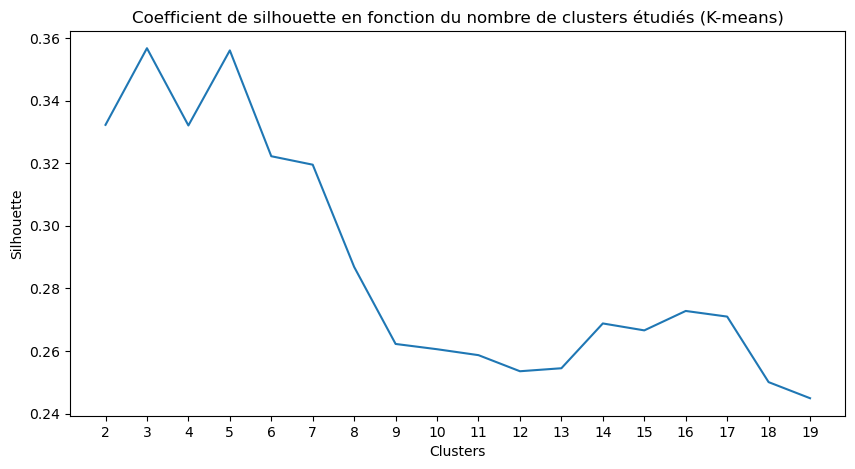

In [37]:
# Choix du nombre de clusters à étudier : utilisation du coefficient de silhouette

from sklearn.metrics import silhouette_score

liste_silhouettes = []                                                                                   # crée une liste qui permettra de récupérer et stocker les coefficients de silhouette de chaque itération du k-means
liste_clusters = range(2, 20)                                                                            # crée une liste contenant le nombre de clusters à étudier (de k = 2 à k = 20)

for k in liste_clusters :                                                                                # crée la boucle qui permet de réaliser le k-means sur chaque nombre de cluster souhaité
    kmeans = KMeans(n_clusters = k, random_state = 42)                                                   # indique l'outil à utiliser (KMeans) et le nombre de clusters à trouver (k), random_state est utilisé pour assurer la reproductibilité des résultats
    kmeans.fit(datas_clust)                                                                              # applique le k-means sur les données corrigées après l'ACP
    if len(np.unique(kmeans.labels_)) > 1 :                                                              # vérifie que le nombre de clusters trouvés est bien > 1 (au moins 2 nécessaire pour calculer le score)
        score = silhouette_score(datas_clust, kmeans.labels_)                                            # calcule le coefficient de silhouette (score > 0.5, proche de 1 = clusters bien séparés / < 0.25 = clustering faible / 0.25 - 0.5 = moyen)
        liste_silhouettes.append(score)                                                                  # récupère le score obtenu et le stocke dans la liste créée précédemment 
    else:
        liste_silhouettes.append(np.nan)

plt.figure(figsize = (10, 5))                                                                            # ajuste la taille du graphique
plt.plot(liste_clusters, liste_silhouettes)                                                              # crée la courbe des scores en fonction du nombre de clusters étudiés
plt.xticks(liste_clusters)                                                                               # assure que chaque cluster est bien marqué sur l'axe des abscisses (x, horizontal)
plt.title("Coefficient de silhouette en fonction du nombre de clusters étudiés (K-means)")               # ajoutent des titres au graphique et aux axes des abscisses (x, horizontal) et ordonnées (y, vertical)
plt.xlabel("Clusters") 
plt.ylabel("Silhouette")
plt.show()                                                                                               # affiche le graphique
    

In [38]:
# Conclusion :

    ## Le silhouette score indique 2 pics (valeurs maximale, ~0.36) à 3 et 5 clusters.
    ## Pour choisir entre ces 2 valeurs, nous allons compléter avec la méthode du coude (Elbow).
    ## Le point d'inflexion du coude (avant 'stabilisation') se situe à 5-6 clusters (3 se situe au centre du coude).
    ## En combinant donc les résultats des 2 indicateurs, il paraît donc plus pertinent de conserver 5 clusters à étudier (valeur commune aux 2 indicateurs).


In [39]:
# Application du k-means sur les données corrigées après l'ACP et avec le nombre de clusters optimal choisi précédement 

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 5,  random_state = 42)                # indique l'outil à utiliser (KMeans) et le nombre de clusters à trouver (5), random_state est utilisé pour assurer la reproductibilité des résultats
kmeans.fit(datas_clust)                                            # applique le k-means sur les données corrigées après l'ACP
print(f"Nous avons bien 5 clusters dont les coordonnées des centoïdes sont : {kmeans.cluster_centers_.round(2)}")

liste_labels = kmeans.labels_                                      # récupère la liste des nouveaux labels des individus (= nom/numéro du cluster associé à l'individu)
for k in range(0, 5) :
    nb_individus = len(liste_labels[liste_labels == k])            # récupère et compte le nombre d'individus présents dans chaque cluster (k)
    print(f"Le cluster {k} contient {nb_individus} individus.") 


Nous avons bien 5 clusters dont les coordonnées des centoïdes sont : [[ 1.8  -0.5   0.39  0.08]
 [-0.21  0.33 -0.9  -0.18]
 [-0.2   5.77  3.56 -0.75]
 [-2.65 -0.59  0.36 -0.25]
 [-2.18  1.01  0.1   5.54]]
Le cluster 0 contient 38 individus.
Le cluster 1 contient 37 individus.
Le cluster 2 contient 3 individus.
Le cluster 3 contient 21 individus.
Le cluster 4 contient 2 individus.


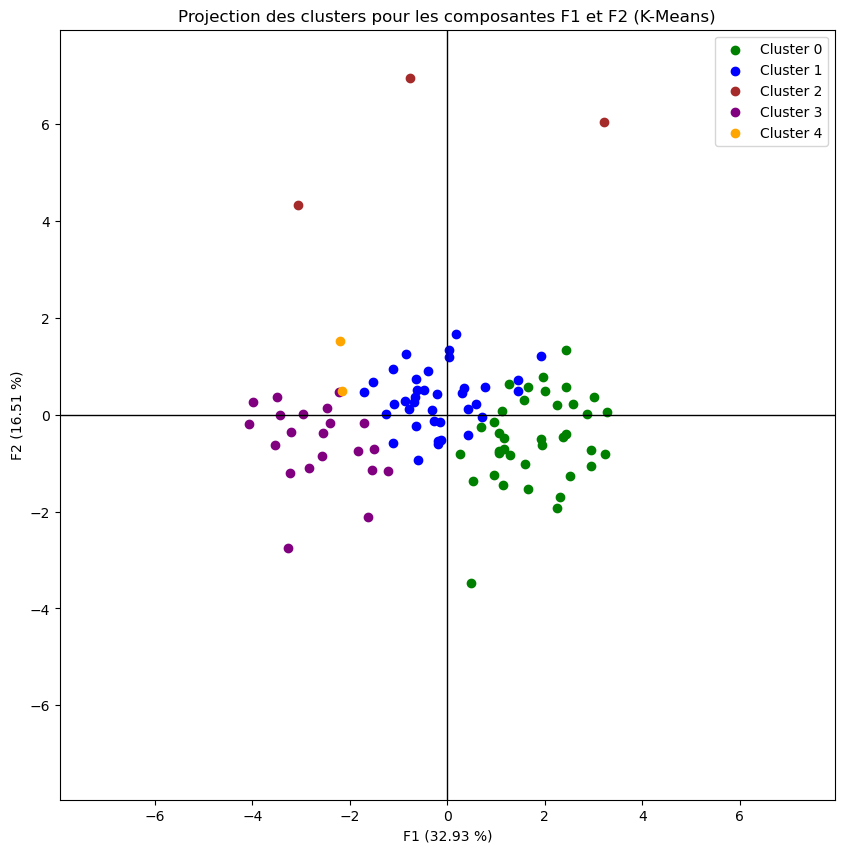

In [40]:
# Affichage des clusters sur les 2 premières composantes de l'ACP (F1 et F2)

colormap = ["green", "blue", "brown", "purple", "orange", "red"]                       # crée une palette de couleur pour afficher les clusters

x = datas_clust[:, 0]                                                                  # récupère les coordonnées de chaque individu correspondant à la composante F1 pour l'axe des abscisses (x, horizontal)          
y = datas_clust[:, 1]                                                                  # récupère les coordonnées de chaque individu correspondant à la composante F2 pour l'axe des ordonnées (y, vertical)

plt.figure(figsize = (10, 10))                                                         # ajuste la taille du graphique
lim = max(max(np.abs(x)), max(np.abs(y))) + 1                                          # récupèrent la valeur maximale pour les coordonnées sur les axes des abscisses (x, horizontal) et ordonnées (y, vertical)
plt.xlim(-lim, lim)                                                                    # appliquent les limites aux axes des abscisses (x, horizontal) et ordonnées (y, vertical)
plt.ylim(-lim, lim)
for i in range(len(set(kmeans.labels_))) :                                             # crée le nuage des individus (nuage de points) pour chaque cluster sur les composantes principales F1 et F2
    plt.scatter(x[kmeans.labels_ == i], y[kmeans.labels_ == i], color = colormap[i], label = f"Cluster {i}")
plt.plot([-lim, lim], [0, 0], color = "black", linewidth = 1)                          # trace l'axe des abscisses (x, horizontal)
plt.plot([0, 0], [-lim, lim], color = "black", linewidth = 1)                          # trace l'axe des ordonnées (y, vertical)
plt.title("Projection des clusters pour les composantes F1 et F2 (K-Means)")           # ajoutent un titre au graphique et aux axes des abscisses (x, horizontal) et ordonnées (y, vertical)
plt.xlabel(f"F1 ({inerties[0].round(2)} %)")                                   
plt.ylabel(f"F2 ({inerties[1].round(2)} %)")
plt.legend()                                                                           # affiche la légende du graphique
plt.show()                                                                             # affiche le graphique final


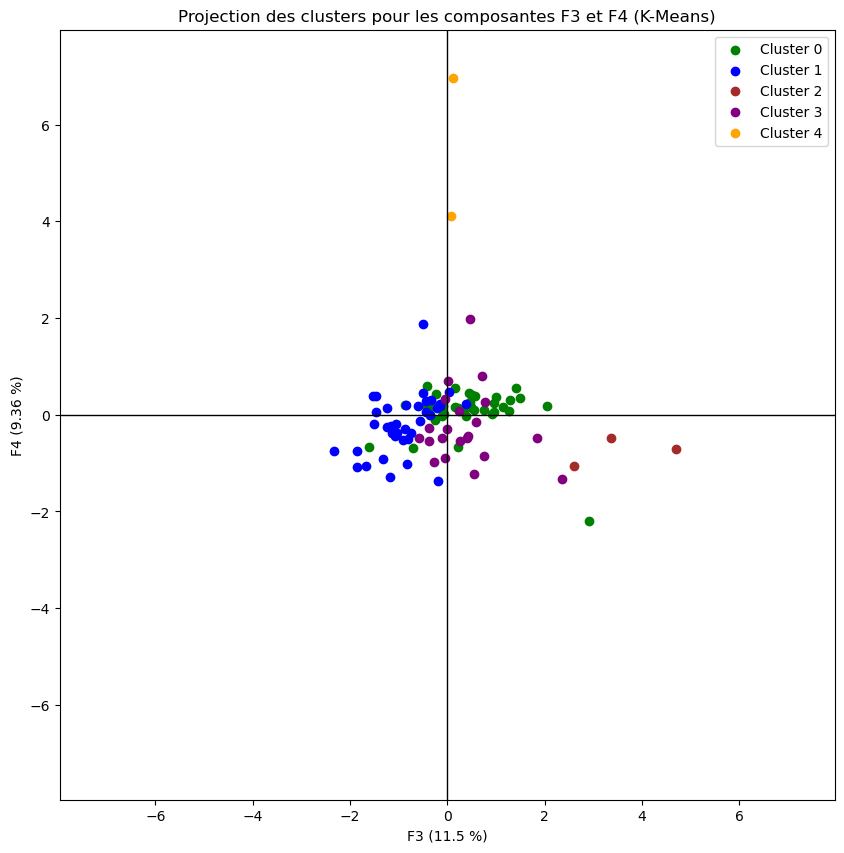

In [41]:
# Affichage des clusters sur les composantes F3 et F4 de l'ACP

colormap = ["green", "blue", "brown", "purple", "orange", "red"]                       # crée une palette de couleur pour afficher les clusters

x = datas_clust[:, 2]                                                                  # récupère les coordonnées de chaque individu correspondant à la composante F3 pour l'axe des abscisses (x, horizontal)          
y = datas_clust[:, 3]                                                                  # récupère les coordonnées de chaque individu correspondant à la composante F4 pour l'axe des ordonnées (y, vertical)

plt.figure(figsize = (10, 10))                                                         # ajuste la taille du graphique
lim = max(max(np.abs(x)), max(np.abs(y))) + 1                                          # récupèrent la valeur maximale pour les coordonnées sur les axes des abscisses (x, horizontal) et ordonnées (y, vertical)
plt.xlim(-lim, lim)                                                                    # appliquent les limites aux axes des abscisses (x, horizontal) et ordonnées (y, vertical)
plt.ylim(-lim, lim)
for i in range(len(set(kmeans.labels_))) :                                             # crée le nuage des individus (nuage de points) pour chaque cluster sur les composantes principales F3 et F4
    plt.scatter(x[kmeans.labels_ == i], y[kmeans.labels_ == i], color = colormap[i], label = f"Cluster {i}")
plt.plot([-lim, lim], [0, 0], color = "black", linewidth = 1)                          # trace l'axe des abscisses (x, horizontal)
plt.plot([0, 0], [-lim, lim], color = "black", linewidth = 1)                          # trace l'axe des ordonnées (y, vertical)
plt.title("Projection des clusters pour les composantes F3 et F4 (K-Means)")           # ajoutent un titre au graphique et aux axes des abscisses (x, horizontal) et ordonnées (y, vertical)
plt.xlabel(f"F3 ({inerties[2].round(2)} %)")                                   
plt.ylabel(f"F4 ({inerties[3].round(2)} %)")
plt.legend()                                                                           # affiche la légende du graphique
plt.show()                                                                             # affiche le graphique final


In [42]:
# Ajout de l'information du numéro de cluster associé pour chaque individu dans le tableau des données initiales

datas["Cluster_KMeans"] = kmeans.labels_ 
datas.head()                                  # affiche les 5 premières lignes du tableau pour vérifier que la modification a été apportée et est correcte


,Population_totale,%Population_urbaine,PIB,Pouvoir_achat,Taux_change,%conso_volaille,%import_volaille,%Accès_internet,%Droits_douanes,Stabilite_politique,%Agri_bio,Cluster_CAH,Cluster_KMeans
Pays,,,,,,,,,,,,,
ALBANIE,2884169.0,60.33,1.301973e+10,4357.51,119.100000,1.29,80.85,62.4000,0.85,0.373771,0.05,1,1
ALGÉRIE,41389189.0,71.93,1.700970e+11,3584.64,110.973017,0.80,0.76,47.6911,9.38,-0.919614,0.00,3,1
ALLEMAGNE,82658409.0,76.75,3.763092e+12,44574.38,0.885206,2.06,52.33,84.3942,1.96,0.574381,8.21,0,0
ARABIE SAOUDITE,33101179.0,83.21,7.149947e+11,23294.86,3.750000,7.93,50.31,94.1756,4.85,-0.649626,0.01,0,1
ARGENTINE,43937140.0,92.45,6.436284e+11,10397.42,16.562707,5.44,0.43,74.2949,7.93,0.162542,3.04,1,1


In [43]:
# Vérification des 3 pays qui semblent mal partitionnés sur F1-F2

liste_cah = datas.index[datas["Cluster_CAH"] == 0]                                 # récupère les noms des pays situés dans le cluster 0 issu de la CAH et les stocke dans une liste
liste_kmeans = datas.index[datas["Cluster_KMeans"] == 1]                           # récupère les noms des pays situés dans le cluster 1 issu du K-Means et les stocke dans une liste
points_communs = list(set(liste_cah) & set(liste_kmeans))                          # compare les noms trouvés dans les 2 listes de pays et ne conserve que ceux qui sont présents dans les 2 listes (communs, grâce à '&')
print(f"Les 3 points bleus qui semblent mal partitionnés (dans cluster 1 - bleu, au lieu de 0 - vert) sont {points_communs}.")

liste_kmeans0 = list(datas.index[datas["Cluster_KMeans"] == 0])                    # récupère les noms des pays situés dans le cluster 0 issu du K-Means et les stocke dans une liste
liste_comparaison = list(set(liste_kmeans0 + points_communs))                      # crée une liste qui contient à la fois les pays présents de le cluster 0 issu du K-Means et ceux communs aux 2 clusters précédents
df_comparaison = copy.deepcopy(datas.loc[datas.index.isin(liste_comparaison), :])  # récupère une copie des données des pays à compoarer et les stocke dans un nouveau dataframe pour ne pas compromettre les données initiales
df_comparaison                                                                     # affiche le nouveau tableau
                                                                                
## => à 1ère vue ces pays semblent similaires aux autres pays du cluster 0 du K-Means (Pop_totale, %pop_urbaine, PIB et pouvoir d'achat, accès internet élevés, droits de douanes faibles, peu consommateurs de volaille
## mais importateurs) mais leur différence pourrait s'expliquer par un politique instable pour l'Arabie Saoudite et l'Israël (-0.6 et -0.9) et un taux de change extrêment élevé pour le Chili. 
## Donc ce n'est peut être pas si étonnant de les trouver dans un autre cluster après le K-Means.


Les 3 points bleus qui semblent mal partitionnés (dans cluster 1 - bleu, au lieu de 0 - vert) sont ['ARABIE SAOUDITE', 'CHILI', 'ISRAËL'].


,Population_totale,%Population_urbaine,PIB,Pouvoir_achat,Taux_change,%conso_volaille,%import_volaille,%Accès_internet,%Droits_douanes,Stabilite_politique,%Agri_bio,Cluster_CAH,Cluster_KMeans
Pays,,,,,,,,,,,,,
ALLEMAGNE,82658409.0,76.75,3.763092e+12,44574.38,0.885206,2.06,52.33,84.3942,1.96,0.574381,8.21,0,0
ARABIE SAOUDITE,33101179.0,83.21,7.149947e+11,23294.86,3.750000,7.93,50.31,94.1756,4.85,-0.649626,0.01,0,1
AUSTRALIE,24584620.0,85.44,1.411790e+12,53626.95,1.304758,5.25,1.37,86.5450,0.89,0.876064,9.59,0,0
AUTRICHE,8819901.0,57.54,4.149261e+11,45612.64,0.885206,1.95,68.75,87.9356,1.96,1.029625,23.38,0,0
BELGIQUE,11419748.0,98.04,5.009088e+11,42823.83,0.885206,1.24,234.72,87.6797,1.96,0.417607,6.28,0,0
CANADA,36732095.0,81.11,1.649266e+12,42927.15,1.297936,4.22,12.70,92.7014,1.52,1.089681,2.05,0,0
CHILI,18470439.0,85.52,2.763649e+11,13494.22,648.833793,5.38,23.07,82.3275,0.49,0.406282,0.16,0,1
CHYPRE,1179678.0,66.83,2.294654e+10,17900.21,0.885206,3.73,46.67,80.7432,1.96,0.530974,4.61,1,0
CROATIE,4182857.0,56.75,5.657333e+10,13752.19,0.879133,1.06,53.33,67.0962,1.96,0.681906,6.46,1,0


In [44]:
# Conclusion :

cluster_kmeans = 0                                                          # indication du n° de cluster contenant les pays qui semblent être des bons candidats pour l'exportation de poulet
liste_pays_kmeans = datas.index[datas["Cluster_KMeans"] == cluster_kmeans]  # récupère la liste des pays présents dans le cluster choisi

print(f"Les pays qui semblent être les meilleurs candidats pour l'exportation des poulets de La Poule qui Chante sont ceux du cluster {cluster_kmeans}.")
print(f"Ce groupe contient {len(liste_pays_kmeans)} pays et semble correspondre aux pays développés, modernisés (accès à internet) et ouverts au marché international (F1 positif), de taille et richesse moyenne (en capacité d'acheter, F2 centré),") 
print(f"consommateurs et importateurs moyens de viande de volaille (F2 centré mais vers le négatif et F3 centré mais vers le positif) et pas forcément pratiquants de l'agriculture biologique mais pas contres non plus (F4 centré + 1 point négatif).")
print(f"Liste des pays : {liste_pays_kmeans}")

# les individus de ce cluster sont également bien représentés sur le plan F1-F2. Leur interprétation est donc fiable sur ce plan (pays riches développés et ouverts).
# En revanche, ils sont moins bien représentés sur le plan F3-F4. L'interprétation de la consommation et importation de volaille et de la pratique de l'agriculture biologique peut être prise en compte mais à modérer.


Les pays qui semblent être les meilleurs candidats pour l'exportation des poulets de La Poule qui Chante sont ceux du cluster 0.
Ce groupe contient 38 pays et semble correspondre aux pays développés, modernisés (accès à internet) et ouverts au marché international (F1 positif), de taille et richesse moyenne (en capacité d'acheter, F2 centré),
consommateurs et importateurs moyens de viande de volaille (F2 centré mais vers le négatif et F3 centré mais vers le positif) et pas forcément pratiquants de l'agriculture biologique mais pas contres non plus (F4 centré + 1 point négatif).
Liste des pays : Index(['ALLEMAGNE', 'AUSTRALIE', 'AUTRICHE', 'BELGIQUE', 'CANADA', 'CHYPRE',
       'CROATIE', 'DANEMARK', 'DOMINIQUE', 'ÉMIRATS ARABES UNIS', 'ESPAGNE',
       'ESTONIE', 'FINLANDE', 'FRANCE', 'GRÈCE', 'HONGRIE', 'IRLANDE',
       'ISLANDE', 'ITALIE', 'JAPON', 'KOWEÏT', 'LETTONIE', 'LITUANIE', 'MALTE',
       'NORVÈGE', 'NOUVELLE-ZÉLANDE', 'OMAN', 'PAYS-BAS', 'PORTUGAL',
       'RÉPUBLIQUE DE C

<div style="background-color: RGB(189,236,182);" >
<h2 style="margin: auto; padding: 20px; color: black; ">CHOIX FINAL DES PAYS</h2>
</div>

In [45]:
# Comparaison des noms de pays présents dans les clusters choisis après la CAH (cluster 0) et le K-Means (cluster 0)

pays_communs = list(set(liste_pays_cah) & set(liste_pays_kmeans))     # compare les noms trouvés dans chaque liste de pays et ne conserve que ceux qui sont présents dans les 2 listes (communs, grâce à '&')
print(f"Il y a {len(liste_pays_cah)} pays dans le cluster sélectionné après la CAH, et {len(liste_pays_kmeans)} pays dans le cluster sélectionné après le K-Means. Parmi eux, {len(pays_communs)} sont communs aux 2 clusters.")
print(pays_communs)

## => pour être sûrs de la validité de notre choix final de pays candidats, nous n'allons conserver que les 33 pays communs aux 2 clusters pour le reste de l'analyse (car nous ne savons pas pourquoi certains ont été sélectionné dans l'un et pas dans l'autre).


Il y a 36 pays dans le cluster sélectionné après la CAH, et 38 pays dans le cluster sélectionné après le K-Means. Parmi eux, 33 sont communs aux 2 clusters.
['FRANCE', 'SLOVAQUIE', 'IRLANDE', 'SLOVÉNIE', 'ÉMIRATS ARABES UNIS', 'TCHÉQUIE', 'SUÈDE', 'LETTONIE', 'SUISSE', 'BELGIQUE', 'MALTE', 'OMAN', 'URUGUAY', 'ALLEMAGNE', 'ISLANDE', 'DANEMARK', "ROYAUME-UNI DE GRANDE-BRETAGNE ET D'IRLANDE DU NORD", 'FINLANDE', 'ESPAGNE', 'NORVÈGE', 'LITUANIE', 'AUTRICHE', 'PAYS-BAS', 'JAPON', 'CANADA', 'KOWEÏT', 'ITALIE', 'PORTUGAL', 'RÉPUBLIQUE DE CORÉE', 'ESTONIE', 'AUSTRALIE', 'NOUVELLE-ZÉLANDE', 'DOMINIQUE']


In [46]:
# Affichage des données pour les 33 pays sélectionnés

pays_candidats = copy.deepcopy(datas.loc[datas.index.isin(pays_communs), :])     # récupère une copie des données des 33 pays et les stocke dans un nouveau dataframe pour ne pas compromettre les données initiales
pays_candidats                                                                   # affiche le nouveau tableau


,Population_totale,%Population_urbaine,PIB,Pouvoir_achat,Taux_change,%conso_volaille,%import_volaille,%Accès_internet,%Droits_douanes,Stabilite_politique,%Agri_bio,Cluster_CAH,Cluster_KMeans
Pays,,,,,,,,,,,,,
ALLEMAGNE,82658409.0,76.75,3.763092e+12,44574.38,0.885206,2.06,52.33,84.3942,1.96,0.574381,8.21,0,0
AUSTRALIE,24584620.0,85.44,1.411790e+12,53626.95,1.304758,5.25,1.37,86.5450,0.89,0.876064,9.59,0,0
AUTRICHE,8819901.0,57.54,4.149261e+11,45612.64,0.885206,1.95,68.75,87.9356,1.96,1.029625,23.38,0,0
BELGIQUE,11419748.0,98.04,5.009088e+11,42823.83,0.885206,1.24,234.72,87.6797,1.96,0.417607,6.28,0,0
CANADA,36732095.0,81.11,1.649266e+12,42927.15,1.297936,4.22,12.70,92.7014,1.52,1.089681,2.05,0,0
DANEMARK,5732274.0,87.78,3.316106e+11,57972.28,6.602893,3.01,80.12,97.0994,1.96,0.854938,8.60,0,0
DOMINIQUE,71458.0,72.60,5.207000e+08,7057.51,2.700000,4.35,133.33,69.6197,8.30,1.172777,0.96,0,0
ÉMIRATS ARABES UNIS,9487203.0,85.46,3.905168e+11,41101.80,3.672500,6.92,105.10,94.8199,4.75,0.601950,1.10,0,0
ESPAGNE,46647428.0,79.58,1.321754e+12,27547.57,0.885206,3.24,14.46,84.6022,1.96,0.270846,8.73,0,0


In [47]:
# La France étant dans la liste, nous pouvons dire que tout les autres pays présents dans ce tableau ont donc un profil similaire à la France et son comparables avec elle. C'est une bonne nouvelle.
# Nous pouvons tout de même la supprimer car c'est le pays dans lequel nous travaillons et à partir duquel nous souhaitons exporter. Il n'est donc pas considéré candidat.

pays_candidats.drop(index = "FRANCE", inplace = True)         # supprime ce pays du tableau


In [48]:
# Tout ces pays sont plutôt stables politiquement (> 0), peuplés (Pop_totale > 1M), aisés (PIB > 1Mds, Pouvoir_achat élevé, taux de change moyen à élevé >= 1), urbanisés (> 60%) et modernisés (population avec acces_internet > 70%).
# Donc ce sont des pays sans situation géo-politique et/ou difficulté financière pouvant être un frein à l'achat de notre viande de volaille.
# Ces pays sont tous également ouverts au commerce international (droits de douanes < 10% n'impactant pas le coût d'exportation de la viande).

petits_pays = pays_candidats.loc[pays_candidats["Population_totale"] < 1000000, :].index.tolist()    # récupère dans une liste les noms des pays dont la population totale est inférieure à 1M d'habitants
print(f"Petits pays : {petits_pays}")                                                                # affiche cette liste

# => Islande, Malte et la Dominique sont des pays plus petits (îles) mais forts importateurs donc pour le moment nous allons les conserver dans l'analyse.


Petits pays : ['DOMINIQUE', 'ISLANDE', 'MALTE']


In [49]:
# En revanche, certains des pays restants sont à dominante religieuse et nécessitent que pour sa consommation la viande soit halal ou kasher.
# Nous allons également les retirer car nous n'appliquons pas ces méthodes d'élevage et abattage donc nous n'avons pas les certifications nécessaires pour l'exportation dans ces pays.

pays_halal = ["ÉMIRATS ARABES UNIS", "KOWEÏT", "OMAN"]          # liste les pays qui possèdent des restrictions alimentaires religieuses (notamment halal ou kasher)
pays_candidats.drop(index = pays_halal, inplace = True)         # supprime ces pays du tableau


In [50]:
# Enfin nous allons conserver uniquement les pays dont nous sommes sûrs qu'ils importent de la viande de volaille (> 30 %) et ont un attrait pour l'agriculture biologique (pratique > 10 %)

pays_non_import = pays_candidats.loc[pays_candidats["%import_volaille"] < 30, :].index.tolist()       # récupère dans une liste les pays qui n'importent pas ou peu de viande de volaille (importation < 30 %)
print(f"Pays peu importateurs de volaille: {pays_non_import}")                                        # affiche cette liste
pays_candidats.drop(index = pays_non_import, inplace = True)                                          # supprime ces pays du tableau

pays_non_bio = pays_candidats.loc[pays_candidats["%Agri_bio"] < 10, :].index.tolist()                 # récupère dans une liste les pays qui pratiquent peu l'agriculture biologique (% cultures en bio < 10 %)
print(f"Pays encore peu pratiquants en bio: {pays_non_bio}")                                          # affiche cette liste
pays_candidats.drop(index = pays_non_bio, inplace = True)                                             # supprime ces pays du tableau


Pays peu importateurs de volaille: ['AUSTRALIE', 'CANADA', 'ESPAGNE', 'FINLANDE', 'ISLANDE', 'ITALIE', 'NORVÈGE', 'NOUVELLE-ZÉLANDE', 'PORTUGAL', 'RÉPUBLIQUE DE CORÉE', 'URUGUAY']
Pays encore peu pratiquants en bio: ['ALLEMAGNE', 'BELGIQUE', 'DANEMARK', 'DOMINIQUE', 'IRLANDE', 'JAPON', 'LITUANIE', 'MALTE', 'PAYS-BAS', "ROYAUME-UNI DE GRANDE-BRETAGNE ET D'IRLANDE DU NORD", 'SLOVAQUIE', 'SLOVÉNIE']


In [51]:
# Conclusion de l'analyse

print(f"Il reste donc {len(pays_candidats)} pays candidats pour l'exportation de poulets bio par La Poule Qui Chante : {pays_candidats.index.tolist()}.")

## Lors de l'analyse PESTEL, j'avais également ajouter des critères concernant l'empreinte carbone du transport, le respect des normes sanitaires et la vérification des certifications à apporter.
    ## Comme la France, les pays candidats appartiennent tous à l'Union Européenne (sauf la Suisse). Le règlement européen sur l'agriculture biologique, les règles de traçabilité et les normes sanitaires étant donc toutes appliquées de la même manière dans les pays de 
    ## l'UE, nous pouvons donc dire que les certifications et règlementations sont bien vérifiées et validées pour exporter notre poulet biologique dans ces pays.
    ## La Suisse, bien que n'étant pas dans l'UE, reconnait également largement ces certifications et règlementations. Ce ne sera donc pas un frein à l'exportation dans ce pays.
    ## Enfin, la pratique de l'agriculture biologique en France est réglementée de sorte à ce que son empreinte carbone soit le plus minimisée possible. Nous pouvons donc annoncer une production 'faible carbone' pour nos poulet bio.
    ## Les pays candidats étant tous en Europe, il sera donc possible d'effectuer le transport via la route ou le chemin de fer, rendant l'empreinte carbone à nouveau raisonnable.
    ## Les pays candidats étant également sensibles à l'empreinte carbone et l'impact environnemental liés à l'import/export, cela ne devrait pas être un frein au commerce avec eux, plutôt même un argument à notre avantage.


Il reste donc 6 pays candidats pour l'exportation de poulets bio par La Poule Qui Chante : ['AUTRICHE', 'ESTONIE', 'LETTONIE', 'SUÈDE', 'SUISSE', 'TCHÉQUIE'].
